epoch=    0 loss=-0.042249 nll=-0.042249 x0=0.7288
epoch=  500 loss=-0.075717 nll=-0.075717 x0=0.1208
epoch= 1000 loss=-1.627316 nll=-1.627316 x0=0.0841
epoch= 1500 loss=-0.526294 nll=-0.526294 x0=0.0623
epoch= 2000 loss=-2.064322 nll=-2.064322 x0=0.0601
epoch= 2500 loss=1.988306 nll=1.988306 x0=0.0749
epoch= 3000 loss=3.959706 nll=3.959706 x0=0.0886
epoch= 3500 loss=3.617885 nll=3.617885 x0=0.0763
epoch= 4000 loss=3.493582 nll=3.493582 x0=0.0615
epoch= 4500 loss=3.328577 nll=3.328577 x0=0.0481


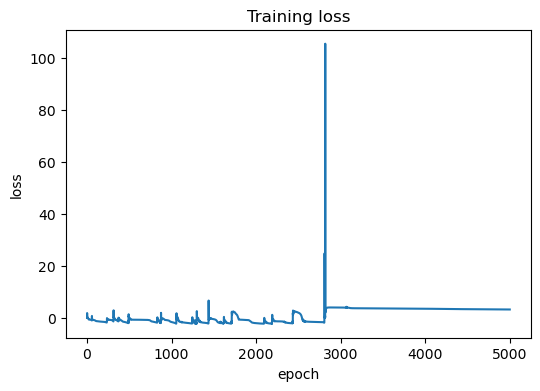

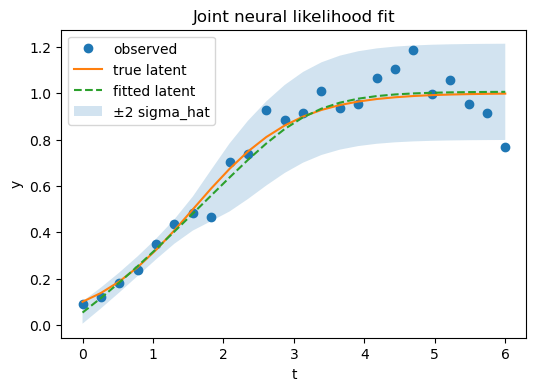

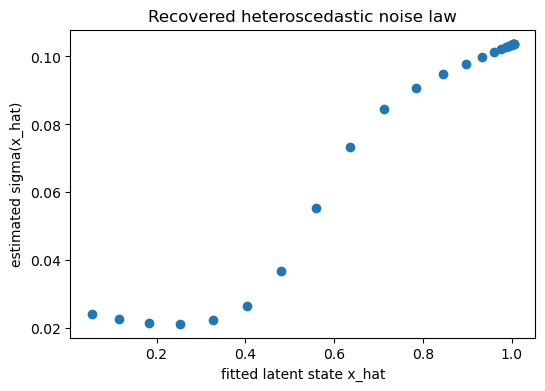

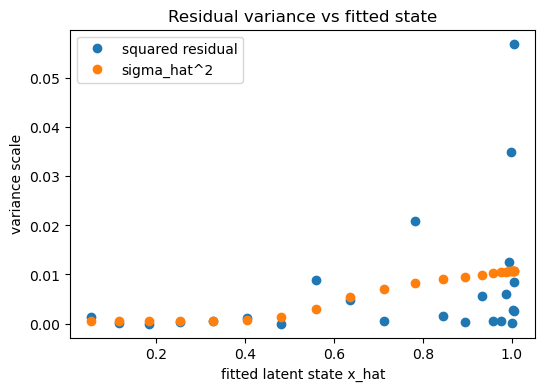

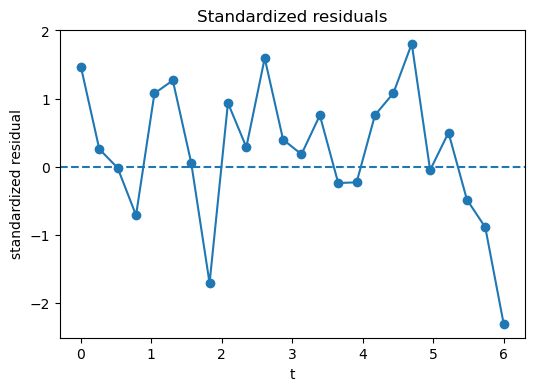

In [89]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# Data from your snippet
# ============================================================
r_true = 1.4
N0 = 0.1
numpts = 4 * (24 // 4)

t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)

def G_true(N):
    return r_true * N * (1.0 - N)

def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)

torch.manual_seed(0)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true


# ============================================================
# 1. Neural RHS model: x' = f_theta(x)
#    Start autonomous for identifiability.
# ============================================================
class DriftNet(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, t, x):
        # x: [batch, 1]
        return self.net(x)


# ============================================================
# 2. Noise model: log sigma(x) = s_phi(x)
#    Softplus / exp makes sigma positive.
# ============================================================
class NoiseNet(nn.Module):
    def __init__(self, hidden=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        # Returns sigma > 0
        log_sigma = self.net(x)
        sigma = torch.exp(log_sigma)
        return sigma, log_sigma


# ============================================================
# 3. Full joint model
# ============================================================
class JointNeuralLikelihoodModel(nn.Module):
    def __init__(self, hidden_drift=32, hidden_noise=16, x0_init=0.05):
        super().__init__()
        self.drift = DriftNet(hidden=hidden_drift)
        self.noise = NoiseNet(hidden=hidden_noise)

        # Learn initial condition too
        self.x0_unconstrained = nn.Parameter(torch.tensor([[x0_init]], dtype=torch.float32))

    def x0(self):
        # Optional positivity constraint if state should stay positive
        return torch.nn.functional.softplus(self.x0_unconstrained)

    def latent_traj(self, t):
        x0 = self.x0()
        x_path = odeint_rk4(self.drift, x0, t.squeeze()).squeeze(1)   # [T,1]
        return x_path

    def nll(self, t, y_obs):
        """
        y_obs: [T,1]
        """
        x_path = self.latent_traj(t)                        # [T,1]
        sigma, log_sigma = self.noise(x_path)              # [T,1], [T,1]

        resid = y_obs - x_path
        nll_pointwise = 0.5 * (resid / sigma)**2 + log_sigma
        nll = nll_pointwise.mean()

        return nll, {
            "x_path": x_path,
            "sigma": sigma,
            "log_sigma": log_sigma,
            "resid": resid,
            "nll_pointwise": nll_pointwise,
        }


# ============================================================
# 4. Regularization
# ============================================================
def smoothness_penalty_on_path(x_path):
    # Penalize curvature in the latent trajectory to avoid wild fits
    if len(x_path) < 3:
        return torch.tensor(0.0, device=x_path.device)
    second_diff = x_path[2:] - 2.0 * x_path[1:-1] + x_path[:-2]
    return (second_diff**2).mean()

def weight_decay(model):
    reg = 0.0
    for p in model.parameters():
        reg = reg + (p**2).sum()
    return reg


# ============================================================
# 5. Train
# ============================================================
y_obs = y_data.detach().clone()   # [T,1]

model = JointNeuralLikelihoodModel(
    hidden_drift=32,
    hidden_noise=16,
    x0_init=0.08
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

loss_history = []
best_state = None
best_loss = float("inf")

for epoch in range(5000):
    optimizer.zero_grad()

    nll, aux = model.nll(t_obs, y_obs)

    x_path = aux["x_path"]
    sigma = aux["sigma"]

    # Mild regularization; tune these
    reg_path = 1e-2 * smoothness_penalty_on_path(x_path)
    reg_w = 1e-6 * weight_decay(model)

    # Optional positivity / boundedness encouragement for sigma
    reg_sigma = 1e-4 * ((sigma - sigma.mean())**2).mean()

    loss = nll #+ reg_path + reg_w + reg_sigma
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = copy.deepcopy(model.state_dict())

    if epoch % 500 == 0:
        print(
            f"epoch={epoch:5d} "
            f"loss={loss.item():.6f} "
            f"nll={nll.item():.6f} "
            f"x0={model.x0().item():.4f}"
        )

model.load_state_dict(best_state)


# ============================================================
# 6. Inspect fitted latent path and recovered noise law
# ============================================================
with torch.no_grad():
    nll, aux = model.nll(t_obs, y_obs)
    x_hat = aux["x_path"]
    sigma_hat = aux["sigma"]
    resid = aux["resid"]
    z_hat = resid / sigma_hat

plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.title("Training loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(t_obs.cpu(), y_obs.cpu(), "o", label="observed")
plt.plot(t_obs.cpu(), y_true.cpu(), "-", label="true latent")
plt.plot(t_obs.cpu(), x_hat.cpu(), "--", label="fitted latent")
plt.fill_between(
    t_obs.squeeze().cpu().numpy(),
    (x_hat - 2*sigma_hat).squeeze().cpu().numpy(),
    (x_hat + 2*sigma_hat).squeeze().cpu().numpy(),
    alpha=0.2,
    label="±2 sigma_hat"
)
plt.legend()
plt.xlabel("t")
plt.ylabel("y")
plt.title("Joint neural likelihood fit")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(x_hat.cpu(), sigma_hat.cpu(), "o")
plt.xlabel("fitted latent state x_hat")
plt.ylabel("estimated sigma(x_hat)")
plt.title("Recovered heteroscedastic noise law")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(x_hat.cpu(), (resid**2).cpu(), "o", label="squared residual")
plt.plot(x_hat.cpu(), (sigma_hat**2).cpu(), "o", label="sigma_hat^2")
plt.xlabel("fitted latent state x_hat")
plt.ylabel("variance scale")
plt.legend()
plt.title("Residual variance vs fitted state")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(t_obs.cpu(), z_hat.cpu(), "o-")
plt.axhline(0.0, linestyle="--")
plt.xlabel("t")
plt.ylabel("standardized residual")
plt.title("Standardized residuals")
plt.show()

In [51]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.4
N0 = 0.1
numpts = 4 * (24 // 4)

t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data
#    Noise law is heteroscedastic: sigma_true(N) = 0.1 N
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)

torch.manual_seed(0)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true


# ============================================================
# 3. Neural RHS model: x' = f_theta(x)
#    Autonomous drift model for identifiability.
# ============================================================
class DriftNet(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, t, x):
        return self.net(x)


# ============================================================
# 4. Noise model: log sigma(x) = s_phi(x)
# ============================================================
class NoiseNet(nn.Module):
    def __init__(self, hidden=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        log_sigma = self.net(x)
        sigma = torch.exp(log_sigma)
        return sigma, log_sigma


# ============================================================
# 5. Proxy network: fit realized residual magnitude as a function of N
#    This is only a visual proxy, not a principled likelihood model.
# ============================================================
class ResidualProxyNet(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return torch.nn.functional.softplus(self.net(x))


# ============================================================
# 6. Full joint model
# ============================================================
class JointNeuralLikelihoodModel(nn.Module):
    def __init__(self, hidden_drift=32, hidden_noise=16, x0_init=0.05):
        super().__init__()
        self.drift = DriftNet(hidden=hidden_drift)
        self.noise = NoiseNet(hidden=hidden_noise)
        self.x0_unconstrained = nn.Parameter(torch.tensor([[x0_init]], dtype=torch.float32))

    def x0(self):
        return torch.nn.functional.softplus(self.x0_unconstrained)

    def latent_traj(self, t):
        x0 = self.x0()
        x_path = odeint_rk4(self.drift, x0, t.squeeze()).squeeze(1)   # [T,1]
        return x_path

    def nll(self, t, y_obs):
        x_path = self.latent_traj(t)                  # [T,1]
        sigma, log_sigma = self.noise(x_path)         # [T,1], [T,1]

        resid = y_obs - x_path
        nll_pointwise = 0.5 * (resid / sigma) ** 2 + log_sigma
        nll = nll_pointwise.sum()

        return nll, {
            "x_path": x_path,
            "sigma": sigma,
            "log_sigma": log_sigma,
            "resid": resid,
            "nll_pointwise": nll_pointwise,
        }


# ============================================================
# 7. Regularization helpers
#    Use .sum() everywhere, per request.
# ============================================================
def smoothness_penalty_on_path(x_path):
    if len(x_path) < 3:
        return torch.tensor(0.0, device=x_path.device)
    second_diff = x_path[2:] - 2.0 * x_path[1:-1] + x_path[:-2]
    return (second_diff ** 2).sum()

def weight_decay(model):
    reg = 0.0
    for p in model.parameters():
        reg = reg + (p ** 2).sum()
    return reg

def monotonicity_penalty_sigma(x_ref, sigma_ref):
    """
    Soft monotonicity penalty encouraging sigma(x) to be nondecreasing in x.

    We sort by x and penalize negative forward differences:
        sigma_{i+1} - sigma_i < 0

    Uses a ReLU soft constraint and .sum().
    """
    x_flat = x_ref.squeeze(-1)
    sigma_flat = sigma_ref.squeeze(-1)

    idx = torch.argsort(x_flat)
    sigma_sorted = sigma_flat[idx]

    dsigma = sigma_sorted[1:] - sigma_sorted[:-1]
    penalty = torch.relu(-dsigma).sum()
    return penalty

def sigma_anchor_penalty(sigma):
    """
    Mild stabilization to keep sigma from becoming arbitrarily rough/large.
    """
    return ((sigma - sigma.mean()) ** 2).sum()


# ============================================================
# 8. Train joint neural likelihood model
# ============================================================
y_obs = y_data.detach().clone()

model = JointNeuralLikelihoodModel(
    hidden_drift=8,
    hidden_noise=4,
    x0_init=0.08
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)

loss_history = []
best_state = None
best_loss = float("inf")

for epoch in range(5000):
    optimizer.zero_grad()

    nll, aux = model.nll(t_obs, y_obs)
    x_path = aux["x_path"]
    sigma = aux["sigma"]

    # Soft monotonicity is enforced on sigma as a function of latent state x_path
    reg_path = 1e-2 * smoothness_penalty_on_path(x_path)
    reg_w = 1e-6 * weight_decay(model)
    reg_sigma = 1e-4 * sigma_anchor_penalty(sigma)
    reg_mono = 1.0 * monotonicity_penalty_sigma(x_path.detach(), sigma)

    loss = nll + reg_mono
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = copy.deepcopy(model.state_dict())

    if epoch % 500 == 0:
        print(
            f"epoch={epoch:5d} "
            f"loss={loss.item():.6f} "
            f"nll={nll.item():.6f} "
            f"mono={reg_mono.item():.6f} "
            f"x0={model.x0().item():.4f}"
        )

model.load_state_dict(best_state)


# ============================================================
# 9. Train proxy NN on realized residual magnitudes
#    Use scaled |residual| so the target is comparable to sigma
#    under a Gaussian assumption: E|Z| = sqrt(2/pi).
#    Also apply the same soft monotonicity penalty.
# ============================================================
with torch.no_grad():
    actual_resid = y_data - y_true
    actual_abs_resid = actual_resid.abs()
    scaled_abs_resid = actual_abs_resid * np.sqrt(np.pi / 2.0)

proxy_net = ResidualProxyNet(hidden=4).to(device)
proxy_optim = torch.optim.Adam(proxy_net.parameters(), lr=1e-3)

proxy_loss_history = []
best_proxy_state = None
best_proxy_loss = float("inf")

for epoch in range(1000):
    proxy_optim.zero_grad()

    pred_scaled_abs_resid = proxy_net(y_true)

    proxy_data_loss = ((pred_scaled_abs_resid - scaled_abs_resid) ** 2).sum()
    proxy_reg = 1e-6 * sum((p ** 2).sum() for p in proxy_net.parameters())
    proxy_mono = 1.0 * monotonicity_penalty_sigma(y_true, pred_scaled_abs_resid)

    loss = proxy_data_loss + proxy_mono
    loss.backward()
    proxy_optim.step()

    proxy_loss_history.append(loss.item())

    if loss.item() < best_proxy_loss:
        best_proxy_loss = loss.item()
        best_proxy_state = copy.deepcopy(proxy_net.state_dict())

proxy_net.load_state_dict(best_proxy_state)


# ============================================================
# 10. Evaluate fitted objects
# ============================================================
with torch.no_grad():
    nll, aux = model.nll(t_obs, y_obs)

    x_hat = aux["x_path"]
    sigma_hat = aux["sigma"]
    resid = aux["resid"]
    z_hat = resid / sigma_hat

    sigma_true_vals = 0.1 * y_true
    sigma_hat_on_true, _ = model.noise(y_true)
    proxy_sigma_on_true = proxy_net(y_true)

    idx_true = torch.argsort(y_true.squeeze())
    N_true_sorted = y_true[idx_true].squeeze()
    sigma_true_sorted = sigma_true_vals[idx_true].squeeze()
    sigma_hat_true_sorted = sigma_hat_on_true[idx_true].squeeze()
    proxy_sigma_sorted = proxy_sigma_on_true[idx_true].squeeze()
    actual_abs_resid_sorted = actual_abs_resid[idx_true].squeeze()
    scaled_abs_resid_sorted = scaled_abs_resid[idx_true].squeeze()


# ============================================================
# 11. Plot diagnostics
# ============================================================

# Training loss
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title("Training loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

# Proxy training loss
plt.figure(figsize=(6, 4))
plt.plot(proxy_loss_history)
plt.xlabel("epoch")
plt.ylabel("proxy loss")
plt.title("Residual proxy NN training loss")
plt.show()

# Trajectory fit
plt.figure(figsize=(7, 4))
plt.plot(t_obs.cpu(), y_obs.cpu(), "o", label="observed")
plt.plot(t_obs.cpu(), y_true.cpu(), "-", label="true latent")
plt.plot(t_obs.cpu(), x_hat.cpu(), "--", label="fitted latent")
plt.fill_between(
    t_obs.squeeze().cpu().numpy(),
    (x_hat - 2 * sigma_hat).squeeze().cpu().numpy(),
    (x_hat + 2 * sigma_hat).squeeze().cpu().numpy(),
    alpha=0.2,
    label="±2 learned sigma"
)
plt.legend()
plt.xlabel("t")
plt.ylabel("y")
plt.title("Joint neural likelihood fit")
plt.show()

# Main sigma comparison plot
plt.figure(figsize=(8, 5))
plt.plot(
    N_true_sorted.cpu(),
    sigma_true_sorted.cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)=0.1N"
)
plt.plot(
    N_true_sorted.cpu(),
    sigma_hat_true_sorted.cpu(),
    "--",
    linewidth=2,
    label="learned sigma(N)"
)
plt.plot(
    N_true_sorted.cpu(),
    proxy_sigma_sorted.cpu(),
    ":",
    linewidth=2.5,
    label="proxy NN fit to scaled |actual residuals|"
)
plt.scatter(
    y_true.squeeze().cpu(),
    actual_abs_resid.squeeze().cpu(),
    alpha=0.55,
    label="|actual residuals|"
)
plt.scatter(
    y_true.squeeze().cpu(),
    scaled_abs_resid.squeeze().cpu(),
    alpha=0.55,
    label="scaled |actual residuals|"
)
plt.xlabel("latent state N")
plt.ylabel("noise scale / residual magnitude")
plt.title("True sigma(N), learned sigma(N), and proxy residual fit")
plt.legend()
plt.show()

# Residuals: actual vs model residuals
plt.figure(figsize=(7, 4))
plt.axhline(0.0, linestyle="--")
plt.scatter(
    y_true.squeeze().cpu(),
    actual_resid.squeeze().cpu(),
    label="actual residuals: y_data - y_true",
    alpha=0.8
)
plt.scatter(
    x_hat.squeeze().cpu(),
    resid.squeeze().cpu(),
    label="model residuals: y_data - x_hat",
    alpha=0.8
)
plt.xlabel("state")
plt.ylabel("residual")
plt.title("Actual residuals vs model residuals")
plt.legend()
plt.show()

# Squared residuals vs variance curves
plt.figure(figsize=(7, 4))
plt.scatter(
    y_true.squeeze().cpu(),
    (actual_resid ** 2).squeeze().cpu(),
    alpha=0.8,
    label="actual residual^2"
)
plt.plot(
    N_true_sorted.cpu(),
    (sigma_true_sorted ** 2).cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)^2"
)
plt.plot(
    N_true_sorted.cpu(),
    (sigma_hat_true_sorted ** 2).cpu(),
    "--",
    linewidth=2,
    label="learned sigma(N)^2"
)
plt.xlabel("latent state N")
plt.ylabel("variance scale")
plt.title("Actual squared residuals vs true/learned variance")
plt.legend()
plt.show()

# Standardized residuals
plt.figure(figsize=(6, 4))
plt.plot(t_obs.cpu(), z_hat.cpu(), "o-")
plt.axhline(0.0, linestyle="--")
plt.xlabel("t")
plt.ylabel("standardized residual")
plt.title("Standardized residuals")
plt.show()

epoch=    0 loss=13.771957 nll=13.771851 mono=0.000107 x0=0.7329
epoch=  500 loss=-42.648956 nll=-42.675751 mono=0.026796 x0=0.2967
epoch= 1000 loss=-47.706322 nll=-47.707958 mono=0.001636 x0=0.1831


KeyboardInterrupt: 

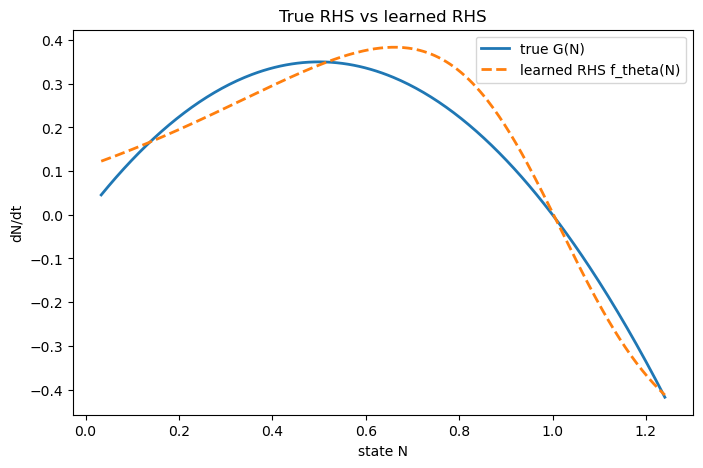

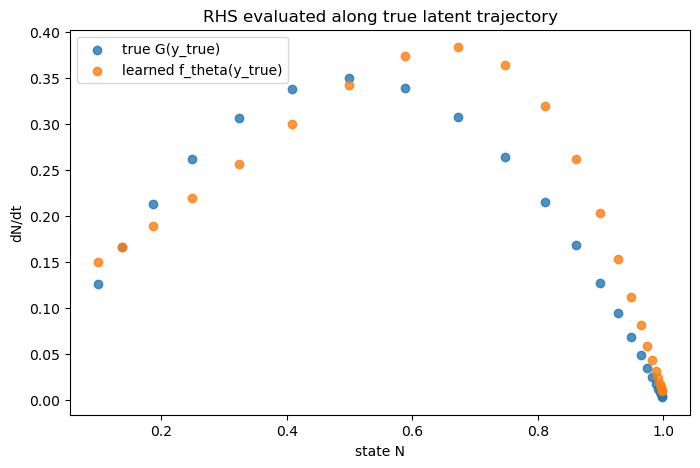

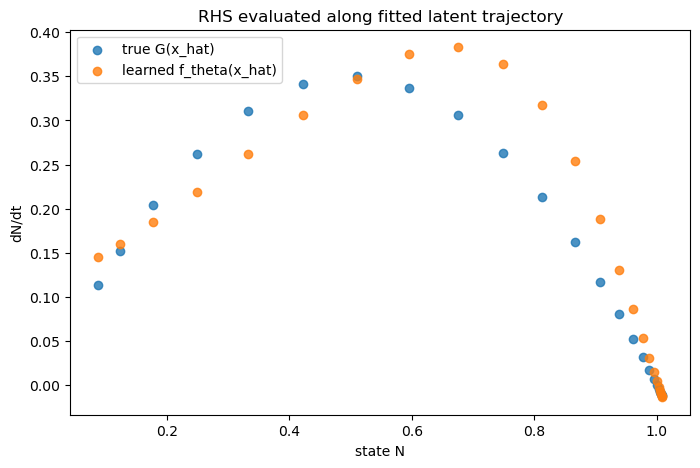

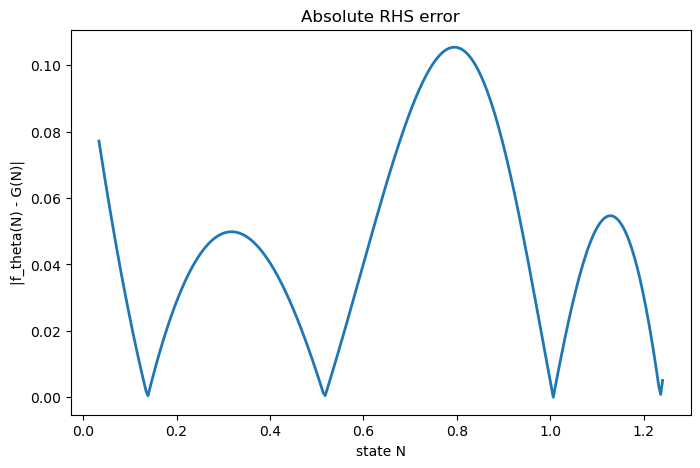

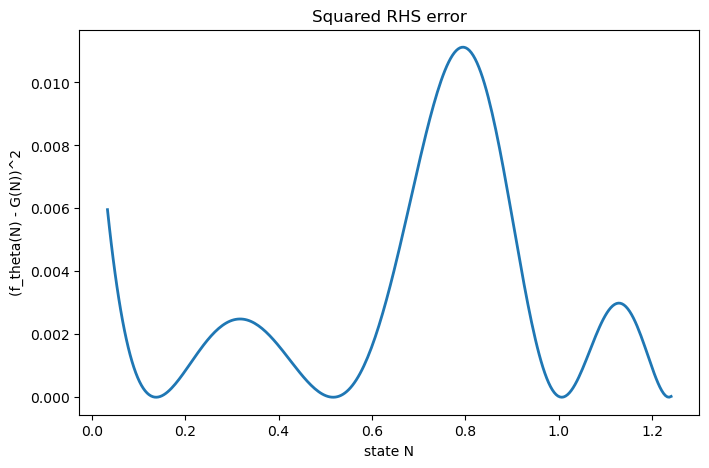

In [74]:
# ============================================================
# 12. Plot learned RHS against the true G(N)
# ============================================================
with torch.no_grad():
    # Choose a grid that covers the relevant state range
    n_min = min(y_true.min().item(), x_hat.min().item(), y_obs.min().item())
    n_max = max(y_true.max().item(), x_hat.max().item(), y_obs.max().item())

    pad = 0.05 * (n_max - n_min + 1e-6)
    N_grid = torch.linspace(n_min - pad, n_max + pad, 300, device=device).view(-1, 1)

    G_true_grid = G_true(N_grid)
    G_learned_grid = model.drift(torch.tensor(0.0, device=device), N_grid)

    # Also evaluate at the true latent states and fitted latent states
    G_true_on_y_true = G_true(y_true)
    G_learned_on_y_true = model.drift(torch.tensor(0.0, device=device), y_true)

    G_true_on_x_hat = G_true(x_hat)
    G_learned_on_x_hat = model.drift(torch.tensor(0.0, device=device), x_hat)

# Smooth curve comparison
plt.figure(figsize=(8, 5))
plt.plot(
    N_grid.cpu().numpy(),
    G_true_grid.cpu().numpy(),
    linewidth=2,
    label="true G(N)"
)
plt.plot(
    N_grid.cpu().numpy(),
    G_learned_grid.cpu().numpy(),
    "--",
    linewidth=2,
    label="learned RHS f_theta(N)"
)
plt.xlabel("state N")
plt.ylabel("dN/dt")
plt.title("True RHS vs learned RHS")
plt.legend()
plt.show()

# Comparison at observed trajectory states
plt.figure(figsize=(8, 5))
plt.scatter(
    y_true.squeeze().cpu().numpy(),
    G_true_on_y_true.squeeze().cpu().numpy(),
    alpha=0.8,
    label="true G(y_true)"
)
plt.scatter(
    y_true.squeeze().cpu().numpy(),
    G_learned_on_y_true.squeeze().cpu().numpy(),
    alpha=0.8,
    label="learned f_theta(y_true)"
)
plt.xlabel("state N")
plt.ylabel("dN/dt")
plt.title("RHS evaluated along true latent trajectory")
plt.legend()
plt.show()

# Comparison at fitted latent states
plt.figure(figsize=(8, 5))
plt.scatter(
    x_hat.squeeze().cpu().numpy(),
    G_true_on_x_hat.squeeze().cpu().numpy(),
    alpha=0.8,
    label="true G(x_hat)"
)
plt.scatter(
    x_hat.squeeze().cpu().numpy(),
    G_learned_on_x_hat.squeeze().cpu().numpy(),
    alpha=0.8,
    label="learned f_theta(x_hat)"
)
plt.xlabel("state N")
plt.ylabel("dN/dt")
plt.title("RHS evaluated along fitted latent trajectory")
plt.legend()
plt.show()

# Pointwise error on the grid
with torch.no_grad():
    rhs_abs_err = (G_learned_grid - G_true_grid).abs()
    rhs_sq_err = (G_learned_grid - G_true_grid) ** 2

plt.figure(figsize=(8, 5))
plt.plot(
    N_grid.cpu().numpy(),
    rhs_abs_err.cpu().numpy(),
    linewidth=2
)
plt.xlabel("state N")
plt.ylabel("|f_theta(N) - G(N)|")
plt.title("Absolute RHS error")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    N_grid.cpu().numpy(),
    rhs_sq_err.cpu().numpy(),
    linewidth=2
)
plt.xlabel("state N")
plt.ylabel("(f_theta(N) - G(N))^2")
plt.title("Squared RHS error")
plt.show()


Running initialization 0

[seed=0] epoch=    0 loss=15.898937 nll=15.890532 mono=0.008391 x0=0.7329
[seed=0] epoch=  500 loss=-31.473598 nll=-31.604002 mono=0.130381 x0=0.3757
[seed=0] epoch= 1000 loss=-42.570919 nll=-42.591644 mono=0.020680 x0=0.2093
[seed=0] epoch= 1500 loss=-52.691608 nll=-52.691681 mono=0.000000 x0=0.1158
[seed=0] epoch= 2000 loss=-58.458488 nll=-58.458580 mono=0.000000 x0=0.0859
[seed=0] epoch= 2500 loss=-59.061802 nll=-59.061897 mono=0.000000 x0=0.0864
[seed=0] fitted power-law proxy: sigma_proxy(N) = 0.104365 * N^1.267980

Running initialization 1

[seed=1] epoch=    0 loss=4.982517 nll=4.953156 mono=0.029350 x0=0.7329
[seed=1] epoch=  500 loss=-42.713371 nll=-42.757904 mono=0.044458 x0=0.2982
[seed=1] epoch= 1000 loss=-46.095207 nll=-46.105507 mono=0.010204 x0=0.2190
[seed=1] epoch= 1500 loss=-47.741486 nll=-47.744179 mono=0.002605 x0=0.1652
[seed=1] epoch= 2000 loss=-48.495224 nll=-48.496258 mono=0.000945 x0=0.1319
[seed=1] epoch= 2500 loss=-48.842915 nll=-48

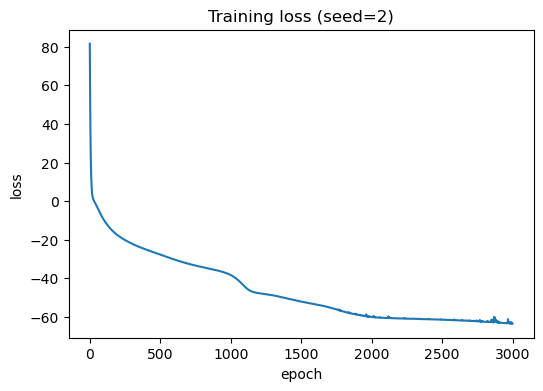

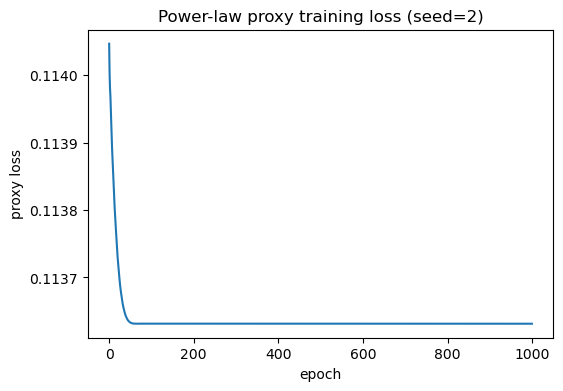

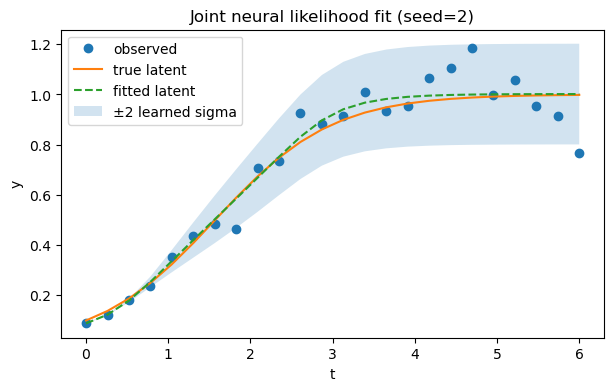

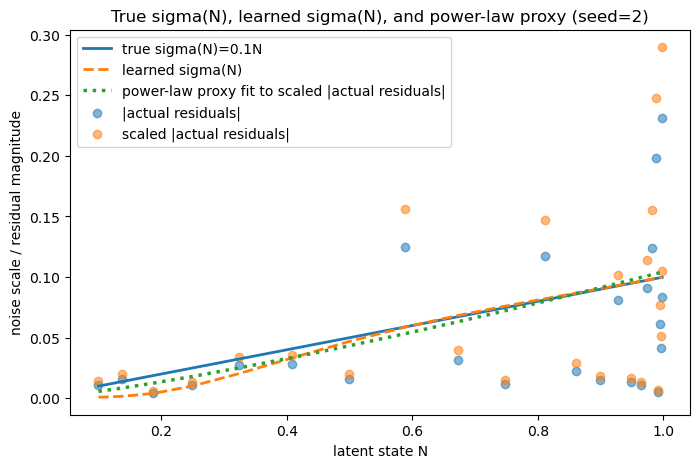

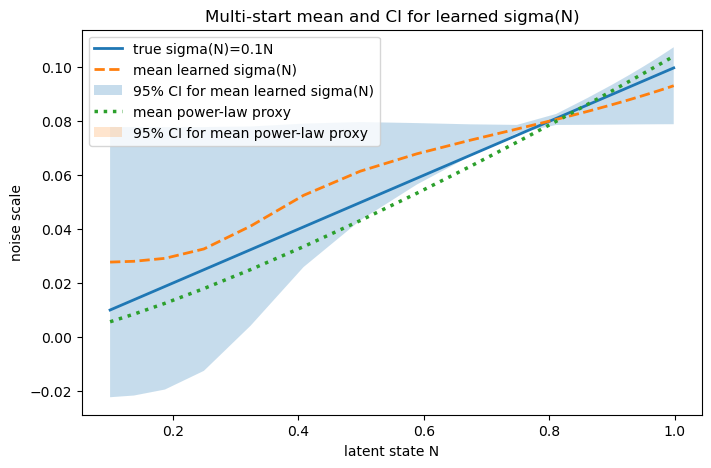

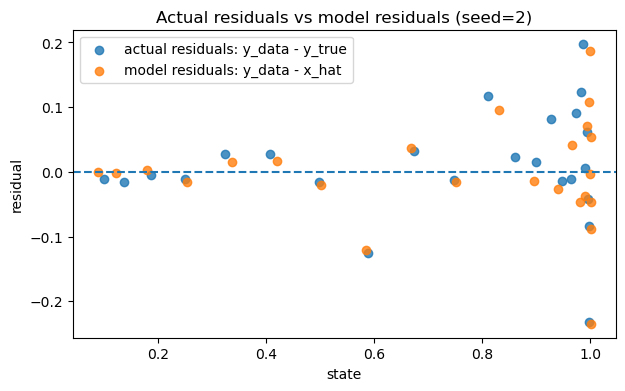

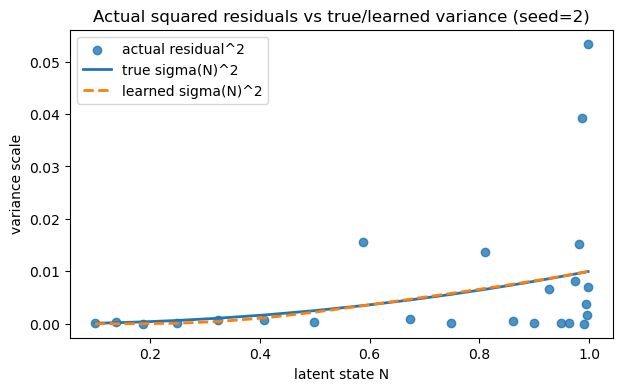

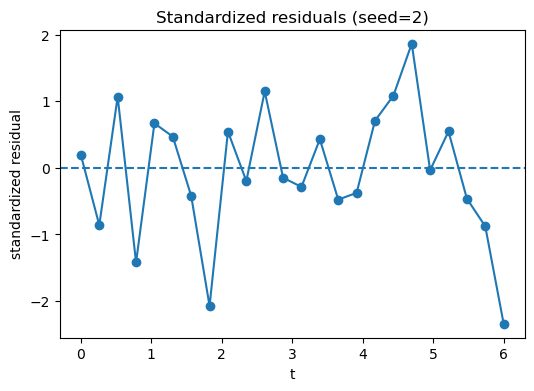

In [ ]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.4
N0 = 0.1
numpts = 4 * (24 // 4)

t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data
#    Noise law is heteroscedastic: sigma_true(N) = 0.1 N
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)

torch.manual_seed(0)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true


# ============================================================
# 3. Neural RHS model: x' = f_theta(x)
#    Autonomous drift model for identifiability.
# ============================================================
class DriftNet(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, t, x):
        return self.net(x)


# ============================================================
# 4. Noise model: log sigma(x) = s_phi(x)
# ============================================================
class NoiseNet(nn.Module):
    def __init__(self, hidden=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        log_sigma = self.net(x)
        sigma = torch.exp(log_sigma)
        return sigma, log_sigma


# ============================================================
# 5. Power-law proxy: sigma_proxy(N) = a * N^b
#    We optimize unconstrained parameters and map them to a,b > 0.
# ============================================================
class PowerLawProxy(nn.Module):
    def __init__(self, a_init=0.1, b_init=1.0):
        super().__init__()

        # inverse-softplus style initialization (approximate)
        a_init_u = np.log(np.exp(a_init) - 1.0) if a_init > 1e-8 else -10.0
        b_init_u = np.log(np.exp(b_init) - 1.0) if b_init > 1e-8 else -10.0

        self.a_unconstrained = nn.Parameter(torch.tensor([a_init_u], dtype=torch.float32))
        self.b_unconstrained = nn.Parameter(torch.tensor([b_init_u], dtype=torch.float32))

    def a(self):
        return torch.nn.functional.softplus(self.a_unconstrained) + 1e-8

    def b(self):
        return torch.nn.functional.softplus(self.b_unconstrained) + 1e-8

    def forward(self, x):
        return self.a() * torch.clamp(x, min=1e-8) ** self.b()


# ============================================================
# 6. Full joint model
# ============================================================
class JointNeuralLikelihoodModel(nn.Module):
    def __init__(self, hidden_drift=32, hidden_noise=16, x0_init=0.05):
        super().__init__()
        self.drift = DriftNet(hidden=hidden_drift)
        self.noise = NoiseNet(hidden=hidden_noise)
        self.x0_unconstrained = nn.Parameter(torch.tensor([[x0_init]], dtype=torch.float32))

    def x0(self):
        return torch.nn.functional.softplus(self.x0_unconstrained)

    def latent_traj(self, t):
        x0 = self.x0()
        x_path = odeint_rk4(self.drift, x0, t.squeeze()).squeeze(1)   # [T,1]
        return x_path

    def nll(self, t, y_obs):
        x_path = self.latent_traj(t)                  # [T,1]
        sigma, log_sigma = self.noise(x_path)         # [T,1], [T,1]

        resid = y_obs - x_path
        nll_pointwise = 0.5 * (resid / sigma) ** 2 + log_sigma
        nll = nll_pointwise.sum()

        return nll, {
            "x_path": x_path,
            "sigma": sigma,
            "log_sigma": log_sigma,
            "resid": resid,
            "nll_pointwise": nll_pointwise,
        }


# ============================================================
# 7. Regularization helpers
#    Use .sum() everywhere, per request.
# ============================================================
def smoothness_penalty_on_path(x_path):
    if len(x_path) < 3:
        return torch.tensor(0.0, device=x_path.device)
    second_diff = x_path[2:] - 2.0 * x_path[1:-1] + x_path[:-2]
    return (second_diff ** 2).sum()

def weight_decay(model):
    reg = 0.0
    for p in model.parameters():
        reg = reg + (p ** 2).sum()
    return reg

def monotonicity_penalty_sigma(x_ref, sigma_ref):
    """
    Soft monotonicity penalty encouraging sigma(x) to be nondecreasing in x.

    We sort by x and penalize negative forward differences:
        sigma_{i+1} - sigma_i < 0

    Uses a ReLU soft constraint and .sum().
    """
    x_flat = x_ref.squeeze(-1)
    sigma_flat = sigma_ref.squeeze(-1)

    idx = torch.argsort(x_flat)
    sigma_sorted = sigma_flat[idx]

    dsigma = sigma_sorted[1:] - sigma_sorted[:-1]
    penalty = torch.relu(-dsigma).sum()
    return penalty

def sigma_anchor_penalty(sigma):
    """
    Mild stabilization to keep sigma from becoming arbitrarily rough/large.
    """
    return ((sigma - sigma.mean()) ** 2).sum()


# ============================================================
# 8. Train + evaluate one run
# ============================================================
def train_and_evaluate(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

    y_obs = y_data.detach().clone()

    model = JointNeuralLikelihoodModel(
        hidden_drift=8,
        hidden_noise=4,
        x0_init=0.08
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)

    loss_history = []
    best_state = None
    best_loss = float("inf")

    for epoch in range(3000):
        optimizer.zero_grad()

        nll, aux = model.nll(t_obs, y_obs)
        x_path = aux["x_path"]
        sigma = aux["sigma"]

        # Soft monotonicity is enforced on sigma as a function of latent state x_path
        reg_path = 1e-2 * smoothness_penalty_on_path(x_path)
        reg_w = 1e-6 * weight_decay(model)
        reg_sigma = 1e-4 * sigma_anchor_penalty(sigma)
        reg_mono = 1.0 * monotonicity_penalty_sigma(x_path.detach(), sigma)

        loss = nll + reg_path + reg_w + reg_sigma + reg_mono
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        if loss.item() < best_loss:
            best_loss = loss.item()
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 500 == 0:
            print(
                f"[seed={seed}] "
                f"epoch={epoch:5d} "
                f"loss={loss.item():.6f} "
                f"nll={nll.item():.6f} "
                f"mono={reg_mono.item():.6f} "
                f"x0={model.x0().item():.4f}"
            )

    model.load_state_dict(best_state)

    # ============================================================
    # 9. Fit power-law proxy on realized residual magnitudes
    #    Use scaled |residual| so target is comparable to sigma
    #    under a Gaussian assumption: E|Z| = sqrt(2/pi)
    # ============================================================
    with torch.no_grad():
        actual_resid = y_data - y_true
        actual_abs_resid = actual_resid.abs()
        scaled_abs_resid = actual_abs_resid * np.sqrt(np.pi / 2.0)

    proxy_model = PowerLawProxy(a_init=0.1, b_init=1.0).to(device)
    proxy_optim = torch.optim.Adam(proxy_model.parameters(), lr=1e-2)

    proxy_loss_history = []
    best_proxy_state = None
    best_proxy_loss = float("inf")

    for epoch in range(1000):
        proxy_optim.zero_grad()

        pred_scaled_abs_resid = proxy_model(y_true)

        proxy_data_loss = ((pred_scaled_abs_resid - scaled_abs_resid) ** 2).sum()
        proxy_reg = 1e-6 * (
            (proxy_model.a_unconstrained ** 2).sum()
            + (proxy_model.b_unconstrained ** 2).sum()
        )
        proxy_mono = 1.0 * monotonicity_penalty_sigma(y_true, pred_scaled_abs_resid)

        loss = proxy_data_loss + proxy_reg + proxy_mono
        loss.backward()
        proxy_optim.step()

        proxy_loss_history.append(loss.item())

        if loss.item() < best_proxy_loss*0.95:
            best_proxy_loss = loss.item()
            best_proxy_state = copy.deepcopy(proxy_model.state_dict())

    proxy_model.load_state_dict(best_proxy_state)

    # ============================================================
    # 10. Evaluate fitted objects
    # ============================================================
    with torch.no_grad():
        nll, aux = model.nll(t_obs, y_obs)

        x_hat = aux["x_path"]
        sigma_hat = aux["sigma"]
        resid = aux["resid"]
        z_hat = resid / sigma_hat

        sigma_true_vals = 0.1 * y_true
        sigma_hat_on_true, _ = model.noise(y_true)
        proxy_sigma_on_true = proxy_model(y_true)

        idx_true = torch.argsort(y_true.squeeze())
        N_true_sorted = y_true[idx_true].squeeze()
        sigma_true_sorted = sigma_true_vals[idx_true].squeeze()
        sigma_hat_true_sorted = sigma_hat_on_true[idx_true].squeeze()
        proxy_sigma_sorted = proxy_sigma_on_true[idx_true].squeeze()
        actual_abs_resid_sorted = actual_abs_resid[idx_true].squeeze()
        scaled_abs_resid_sorted = scaled_abs_resid[idx_true].squeeze()

    return {
        "seed": seed,
        "model": model,
        "proxy_model": proxy_model,
        "loss_history": loss_history,
        "proxy_loss_history": proxy_loss_history,
        "x_hat": x_hat,
        "sigma_hat": sigma_hat,
        "resid": resid,
        "z_hat": z_hat,
        "sigma_true_vals": sigma_true_vals,
        "sigma_hat_on_true": sigma_hat_on_true,
        "proxy_sigma_on_true": proxy_sigma_on_true,
        "actual_resid": actual_resid,
        "actual_abs_resid": actual_abs_resid,
        "scaled_abs_resid": scaled_abs_resid,
        "N_true_sorted": N_true_sorted,
        "sigma_true_sorted": sigma_true_sorted,
        "sigma_hat_true_sorted": sigma_hat_true_sorted,
        "proxy_sigma_sorted": proxy_sigma_sorted,
        "actual_abs_resid_sorted": actual_abs_resid_sorted,
        "scaled_abs_resid_sorted": scaled_abs_resid_sorted,
        "proxy_a": proxy_model.a().item(),
        "proxy_b": proxy_model.b().item(),
    }


# ============================================================
# 11. Run over multiple initializations
# ============================================================
num_runs = 3
results = []

for seed in range(num_runs):
    print("\n===============================")
    print(f"Running initialization {seed}")
    print("===============================\n")
    res = train_and_evaluate(seed)
    results.append(res)
    print(
        f"[seed={seed}] fitted power-law proxy: "
        f"sigma_proxy(N) = {res['proxy_a']:.6f} * N^{res['proxy_b']:.6f}", end="\r",
    )

# choose one representative run for the original-style plots
# here: the run with the smallest final training loss
best_run_idx = int(np.argmin([min(r["loss_history"]) for r in results]))
best_res = results[best_run_idx]

print("\n==========================================")
print(f"Using seed={best_res['seed']} for single-run diagnostic plots")
print("==========================================\n")

loss_history = best_res["loss_history"]
proxy_loss_history = best_res["proxy_loss_history"]
x_hat = best_res["x_hat"]
sigma_hat = best_res["sigma_hat"]
resid = best_res["resid"]
z_hat = best_res["z_hat"]
sigma_true_vals = best_res["sigma_true_vals"]
actual_resid = best_res["actual_resid"]
actual_abs_resid = best_res["actual_abs_resid"]
scaled_abs_resid = best_res["scaled_abs_resid"]
N_true_sorted = best_res["N_true_sorted"]
sigma_true_sorted = best_res["sigma_true_sorted"]
sigma_hat_true_sorted = best_res["sigma_hat_true_sorted"]
proxy_sigma_sorted = best_res["proxy_sigma_sorted"]
actual_abs_resid_sorted = best_res["actual_abs_resid_sorted"]
scaled_abs_resid_sorted = best_res["scaled_abs_resid_sorted"]

# aggregate learned sigma(N) across runs
sigma_runs = torch.stack([r["sigma_hat_on_true"].squeeze() for r in results], dim=0)
sigma_mean = sigma_runs.mean(dim=0)
sigma_std = sigma_runs.std(dim=0, unbiased=True)
sigma_se = sigma_std / np.sqrt(num_runs)
sigma_ci_lower = sigma_mean - 1.96 * sigma_se
sigma_ci_upper = sigma_mean + 1.96 * sigma_se

proxy_runs = torch.stack([r["proxy_sigma_on_true"].squeeze() for r in results], dim=0)
proxy_mean = proxy_runs.mean(dim=0)
proxy_std = proxy_runs.std(dim=0, unbiased=True)
proxy_se = proxy_std / np.sqrt(num_runs)
proxy_ci_lower = proxy_mean - 1.96 * proxy_se
proxy_ci_upper = proxy_mean + 1.96 * proxy_se

idx_true = torch.argsort(y_true.squeeze())
sigma_mean_sorted = sigma_mean[idx_true].squeeze()
sigma_ci_lower_sorted = sigma_ci_lower[idx_true].squeeze()
sigma_ci_upper_sorted = sigma_ci_upper[idx_true].squeeze()
proxy_mean_sorted = proxy_mean[idx_true].squeeze()
proxy_ci_lower_sorted = proxy_ci_lower[idx_true].squeeze()
proxy_ci_upper_sorted = proxy_ci_upper[idx_true].squeeze()


# ============================================================
# 12. Plot diagnostics
# ============================================================

# Training loss
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title(f"Training loss (seed={best_res['seed']})")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

# Proxy training loss
plt.figure(figsize=(6, 4))
plt.plot(proxy_loss_history)
plt.xlabel("epoch")
plt.ylabel("proxy loss")
plt.title(f"Power-law proxy training loss (seed={best_res['seed']})")
plt.show()

# Trajectory fit
plt.figure(figsize=(7, 4))
plt.plot(t_obs.cpu(), y_data.cpu(), "o", label="observed")
plt.plot(t_obs.cpu(), y_true.cpu(), "-", label="true latent")
plt.plot(t_obs.cpu(), x_hat.cpu(), "--", label="fitted latent")
plt.fill_between(
    t_obs.squeeze().cpu().numpy(),
    (x_hat - 2 * sigma_hat).squeeze().cpu().numpy(),
    (x_hat + 2 * sigma_hat).squeeze().cpu().numpy(),
    alpha=0.2,
    label="±2 learned sigma"
)
plt.legend()
plt.xlabel("t")
plt.ylabel("y")
plt.title(f"Joint neural likelihood fit (seed={best_res['seed']})")
plt.show()

# Main sigma comparison plot: single representative run
plt.figure(figsize=(8, 5))
plt.plot(
    N_true_sorted.cpu(),
    sigma_true_sorted.cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)=0.1N"
)
plt.plot(
    N_true_sorted.cpu(),
    sigma_hat_true_sorted.cpu(),
    "--",
    linewidth=2,
    label="learned sigma(N)"
)
plt.plot(
    N_true_sorted.cpu(),
    proxy_sigma_sorted.cpu(),
    ":",
    linewidth=2.5,
    label="power-law proxy fit to scaled |actual residuals|"
)
plt.scatter(
    y_true.squeeze().cpu(),
    actual_abs_resid.squeeze().cpu(),
    alpha=0.55,
    label="|actual residuals|"
)
plt.scatter(
    y_true.squeeze().cpu(),
    scaled_abs_resid.squeeze().cpu(),
    alpha=0.55,
    label="scaled |actual residuals|"
)
plt.xlabel("latent state N")
plt.ylabel("noise scale / residual magnitude")
plt.title(f"True sigma(N), learned sigma(N), and power-law proxy (seed={best_res['seed']})")
plt.legend()
plt.show()

# New multi-start mean CI plot for learned sigma(N)
plt.figure(figsize=(8, 5))
plt.plot(
    N_true_sorted.cpu(),
    sigma_true_sorted.cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)=0.1N"
)
plt.plot(
    N_true_sorted.cpu(),
    sigma_mean_sorted.cpu(),
    "--",
    linewidth=2,
    label="mean learned sigma(N)"
)
plt.fill_between(
    N_true_sorted.cpu().numpy(),
    sigma_ci_lower_sorted.cpu().numpy(),
    sigma_ci_upper_sorted.cpu().numpy(),
    alpha=0.25,
    label="95% CI for mean learned sigma(N)"
)
plt.plot(
    N_true_sorted.cpu(),
    proxy_mean_sorted.cpu(),
    ":",
    linewidth=2.5,
    label="mean power-law proxy"
)
plt.fill_between(
    N_true_sorted.cpu().numpy(),
    proxy_ci_lower_sorted.cpu().numpy(),
    proxy_ci_upper_sorted.cpu().numpy(),
    alpha=0.20,
    label="95% CI for mean power-law proxy"
)
plt.xlabel("latent state N")
plt.ylabel("noise scale")
plt.title("Multi-start mean and CI for learned sigma(N)")
plt.legend()
plt.show()

# Residuals: actual vs model residuals
plt.figure(figsize=(7, 4))
plt.axhline(0.0, linestyle="--")
plt.scatter(
    y_true.squeeze().cpu(),
    actual_resid.squeeze().cpu(),
    label="actual residuals: y_data - y_true",
    alpha=0.8
)
plt.scatter(
    x_hat.squeeze().cpu(),
    resid.squeeze().cpu(),
    label="model residuals: y_data - x_hat",
    alpha=0.8
)
plt.xlabel("state")
plt.ylabel("residual")
plt.title(f"Actual residuals vs model residuals (seed={best_res['seed']})")
plt.legend()
plt.show()

# Squared residuals vs variance curves
plt.figure(figsize=(7, 4))
plt.scatter(
    y_true.squeeze().cpu(),
    (actual_resid ** 2).squeeze().cpu(),
    alpha=0.8,
    label="actual residual^2"
)
plt.plot(
    N_true_sorted.cpu(),
    (sigma_true_sorted ** 2).cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)^2"
)
plt.plot(
    N_true_sorted.cpu(),
    (sigma_hat_true_sorted ** 2).cpu(),
    "--",
    linewidth=2,
    label="learned sigma(N)^2"
)
plt.xlabel("latent state N")
plt.ylabel("variance scale")
plt.title(f"Actual squared residuals vs true/learned variance (seed={best_res['seed']})")
plt.legend()
plt.show()

# Standardized residuals
plt.figure(figsize=(6, 4))
plt.plot(t_obs.cpu(), z_hat.cpu(), "o-")
plt.axhline(0.0, linestyle="--")
plt.xlabel("t")
plt.ylabel("standardized residual")
plt.title(f"Standardized residuals (seed={best_res['seed']})")
plt.show()


Running initialization 0

[seed=0] epoch=    0 loss=15.898924 nll=15.890532 mono=0.008391 x0=0.7334
[seed=0] epoch=  500 loss=-24.735260 nll=-24.750332 mono=0.015072 x0=0.5176
[seed=0] epoch= 1000 loss=-31.789003 nll=-31.952269 mono=0.163265 x0=0.3711
[seed=0] epoch= 1500 loss=-35.206013 nll=-35.325615 mono=0.119603 x0=0.2820
[seed=0] epoch= 2000 loss=-47.303020 nll=-47.307007 mono=0.003987 x0=0.2001
[seed=0] epoch= 2500 loss=-51.415302 nll=-51.416672 mono=0.001370 x0=0.1403
[seed=0] epoch= 3000 loss=-53.656315 nll=-53.656315 mono=0.000000 x0=0.1045
[seed=0] epoch= 3500 loss=-58.581989 nll=-58.581989 mono=0.000000 x0=0.0858
[seed=0] epoch= 4000 loss=-59.016247 nll=-59.016247 mono=0.000000 x0=0.0864
[seed=0] epoch= 4500 loss=-59.271034 nll=-59.271034 mono=0.000000 x0=0.0863
[seed=0] fitted power-law proxy: sigma_proxy(N) = 0.104340 * N^1.265414
[seed=0] status: terminated_early=False reason=completed

Best run is seed=0 with best_loss=-59.658867 at best_epoch=4997



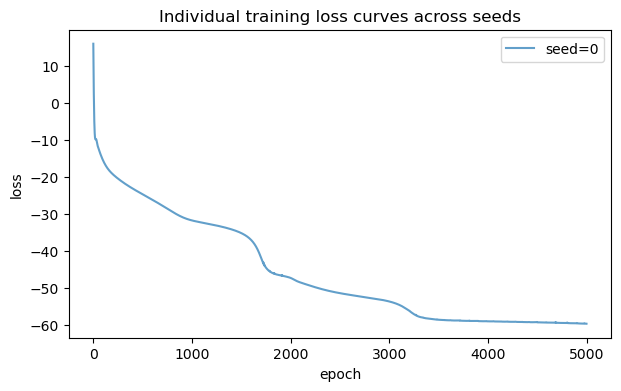

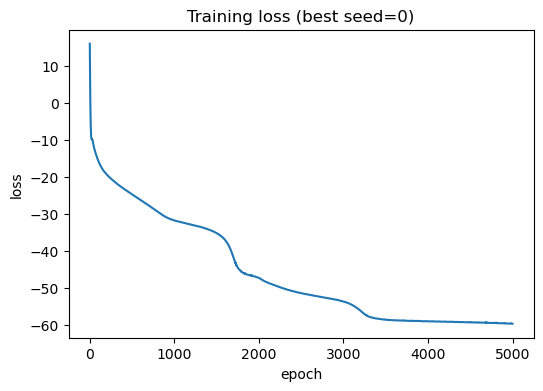

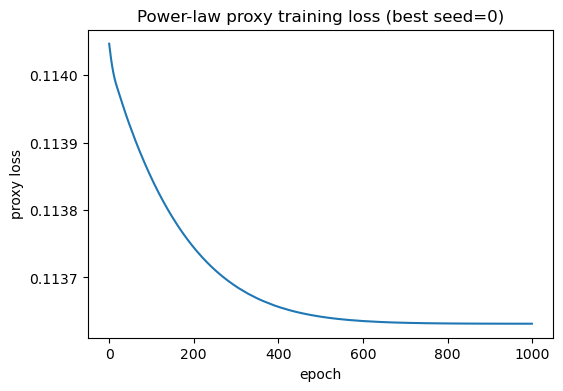

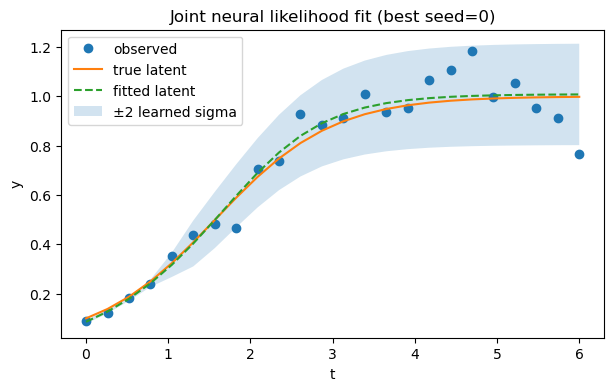

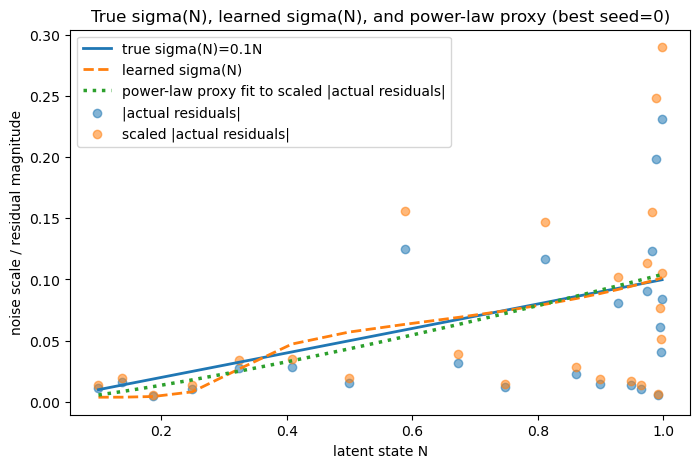

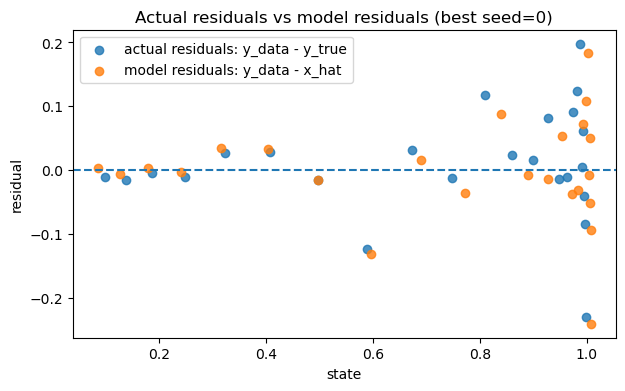

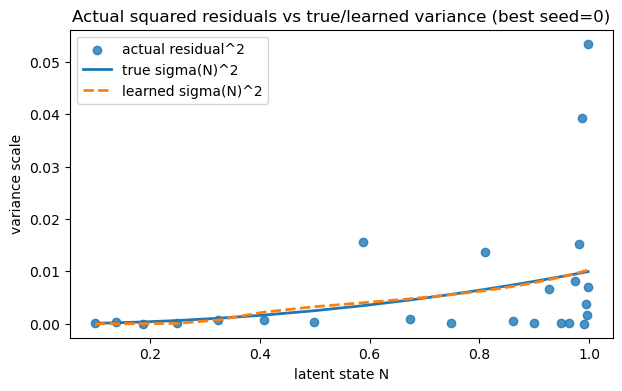

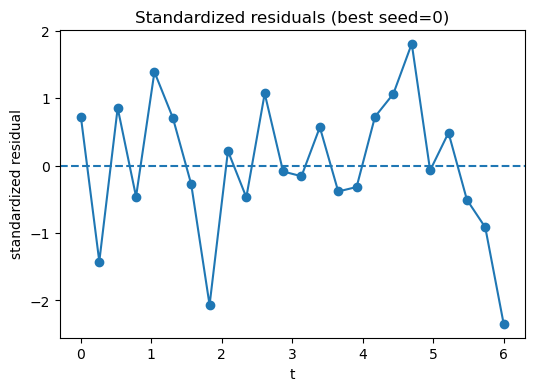

In [56]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.4
N0 = 0.1
numpts = 4 * (24 // 4)

t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data
#    Noise law is heteroscedastic: sigma_true(N) = 0.1 N
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)

torch.manual_seed(0)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true


# ============================================================
# 3. Neural RHS model: x' = f_theta(x)
# ============================================================
class DriftNet(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, t, x):
        return self.net(x)


# ============================================================
# 4. Noise model: log sigma(x) = s_phi(x)
# ============================================================
class NoiseNet(nn.Module):
    def __init__(self, hidden=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        log_sigma = self.net(x)
        sigma = torch.exp(log_sigma)
        return sigma, log_sigma


# ============================================================
# 5. Power-law proxy: sigma_proxy(N) = a * N^b
# ============================================================
class PowerLawProxy(nn.Module):
    def __init__(self, a_init=0.1, b_init=1.0):
        super().__init__()

        a_init_u = np.log(np.exp(a_init) - 1.0) if a_init > 1e-8 else -10.0
        b_init_u = np.log(np.exp(b_init) - 1.0) if b_init > 1e-8 else -10.0

        self.a_unconstrained = nn.Parameter(torch.tensor([a_init_u], dtype=torch.float32))
        self.b_unconstrained = nn.Parameter(torch.tensor([b_init_u], dtype=torch.float32))

    def a(self):
        return torch.nn.functional.softplus(self.a_unconstrained) + 1e-8

    def b(self):
        return torch.nn.functional.softplus(self.b_unconstrained) + 1e-8

    def forward(self, x):
        x_safe = torch.where(x > 0.0, x, torch.full_like(x, 1e-8))
        return self.a() * (x_safe ** self.b())


# ============================================================
# 6. Full joint model
# ============================================================
class JointNeuralLikelihoodModel(nn.Module):
    def __init__(self, hidden_drift=32, hidden_noise=16, x0_init=0.05):
        super().__init__()
        self.drift = DriftNet(hidden=hidden_drift)
        self.noise = NoiseNet(hidden=hidden_noise)
        self.x0_unconstrained = nn.Parameter(torch.tensor([[x0_init]], dtype=torch.float32))

    def x0(self):
        return torch.nn.functional.softplus(self.x0_unconstrained)

    def latent_traj(self, t):
        x0 = self.x0()
        x_path = odeint_rk4(self.drift, x0, t.squeeze()).squeeze(1)
        return x_path

    def nll(self, t, y_obs):
        x_path = self.latent_traj(t)
        sigma, log_sigma = self.noise(x_path)

        resid = y_obs - x_path
        nll_pointwise = 0.5 * (resid / sigma) ** 2 + log_sigma
        nll = nll_pointwise.sum()

        return nll, {
            "x_path": x_path,
            "sigma": sigma,
            "log_sigma": log_sigma,
            "resid": resid,
            "nll_pointwise": nll_pointwise,
        }


# ============================================================
# 7. Regularization helpers
# ============================================================
def smoothness_penalty_on_path(x_path):
    if len(x_path) < 3:
        return torch.tensor(0.0, device=x_path.device)
    second_diff = x_path[2:] - 2.0 * x_path[1:-1] + x_path[:-2]
    return (second_diff ** 2).sum()

def weight_decay(model):
    reg = 0.0
    for p in model.parameters():
        reg = reg + (p ** 2).sum()
    return reg

def monotonicity_penalty_sigma(x_ref, sigma_ref):
    x_flat = x_ref.squeeze(-1)
    sigma_flat = sigma_ref.squeeze(-1)

    idx = torch.argsort(x_flat)
    sigma_sorted = sigma_flat[idx]
    dsigma = sigma_sorted[1:] - sigma_sorted[:-1]
    return torch.relu(-dsigma).sum()

def sigma_anchor_penalty(sigma):
    return ((sigma - sigma.mean()) ** 2).sum()


# ============================================================
# 8. Train + evaluate one run
# ============================================================
def train_and_evaluate(
    seed,
    max_epochs_model=5000,
    max_epochs_proxy=1000,
    spike_factor=10.0,
    patience_after_best=200,
    grad_norm_spike_threshold=1e4,
    x_path_abs_threshold=10.0,
    sigma_abs_threshold=10.0,
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    y_obs = y_data.detach().clone()

    model = JointNeuralLikelihoodModel(
        hidden_drift=8,
        hidden_noise=4,
        x0_init=0.08
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    loss_history = []
    best_state = None
    best_loss = float("inf")
    terminated_early = False
    termination_reason = "completed"
    best_epoch = -1

    for epoch in range(max_epochs_model):
        optimizer.zero_grad()

        nll, aux = model.nll(t_obs, y_obs)
        x_path = aux["x_path"]
        sigma = aux["sigma"]

        #reg_path = 1e-2 * smoothness_penalty_on_path(x_path)
        #reg_w = 1e-6 * weight_decay(model)
        #reg_sigma = 1e-4 * sigma_anchor_penalty(sigma)
        reg_mono = 1.0 * monotonicity_penalty_sigma(x_path.detach(), sigma)

        loss = nll +  reg_mono

        if not torch.isfinite(loss):
            terminated_early = True
            termination_reason = f"non-finite loss at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if not torch.isfinite(x_path).all():
            terminated_early = True
            termination_reason = f"non-finite latent trajectory at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if not torch.isfinite(sigma).all():
            terminated_early = True
            termination_reason = f"non-finite sigma at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        max_abs_x = x_path.abs().max().item()
        max_sigma = sigma.max().item()

        if max_abs_x > x_path_abs_threshold:
            terminated_early = True
            termination_reason = (
                f"latent trajectory exceeded threshold at epoch {epoch} "
                f"(max |x| = {max_abs_x:.6f})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if max_sigma > sigma_abs_threshold:
            terminated_early = True
            termination_reason = (
                f"sigma exceeded threshold at epoch {epoch} "
                f"(max sigma = {max_sigma:.6f})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        loss.backward()

        total_grad_sq = 0.0
        grad_is_finite = True
        for p in model.parameters():
            if p.grad is not None:
                if not torch.isfinite(p.grad).all():
                    grad_is_finite = False
                    break
                total_grad_sq += (p.grad ** 2).sum().item()

        grad_norm = np.sqrt(total_grad_sq) if grad_is_finite else np.inf

        if not np.isfinite(grad_norm):
            terminated_early = True
            termination_reason = f"non-finite gradient norm at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if grad_norm > grad_norm_spike_threshold:
            terminated_early = True
            termination_reason = (
                f"gradient spike at epoch {epoch} "
                f"(grad_norm = {grad_norm:.6e})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        current_loss = loss.item()
        loss_history.append(current_loss)

        if current_loss < best_loss:
            best_loss = current_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        elif best_loss < float("inf") and current_loss > spike_factor + best_loss:

            print("best loss", best_loss)
            print("spiked", spike_factor * best_loss)

            terminated_early = True
            termination_reason = (
                f"loss spike at epoch {epoch} "
                f"(loss = {current_loss:.6e}, best_loss = {best_loss:.6e})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if best_epoch >= 0 and (epoch - best_epoch) > patience_after_best:
            if current_loss > 5.0 * best_loss:
                terminated_early = True
                termination_reason = (
                    f"sustained deterioration after best epoch "
                    f"(epoch = {epoch}, best_epoch = {best_epoch}, "
                    f"loss = {current_loss:.6e}, best_loss = {best_loss:.6e})"
                )
                print(f"[seed={seed}] Terminating: {termination_reason}")
                break

        optimizer.step()

        if epoch % 500 == 0:
            print(
                f"[seed={seed}] "
                f"epoch={epoch:5d} "
                f"loss={loss.item():.6f} "
                f"nll={nll.item():.6f} "
                f"mono={reg_mono.item():.6f} "
                f"x0={model.x0().item():.4f}"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    # ============================================================
    # 9. Fit power-law proxy
    # ============================================================
    with torch.no_grad():
        actual_resid = y_data - y_true
        actual_abs_resid = actual_resid.abs()
        scaled_abs_resid = actual_abs_resid * np.sqrt(np.pi / 2.0)

    proxy_model = PowerLawProxy(a_init=0.1, b_init=1.0).to(device)
    proxy_optim = torch.optim.Adam(proxy_model.parameters(), lr=1e-3)

    proxy_loss_history = []
    best_proxy_state = None
    best_proxy_loss = float("inf")

    for epoch in range(max_epochs_proxy):
        proxy_optim.zero_grad()

        pred_scaled_abs_resid = proxy_model(y_true)

        proxy_data_loss = ((pred_scaled_abs_resid - scaled_abs_resid) ** 2).sum()
        proxy_reg = 1e-6 * (
            (proxy_model.a_unconstrained ** 2).sum() +
            (proxy_model.b_unconstrained ** 2).sum()
        )
        proxy_mono = 1.0 * monotonicity_penalty_sigma(y_true, pred_scaled_abs_resid)

        loss = proxy_data_loss + proxy_reg + proxy_mono
        loss.backward()
        proxy_optim.step()

        proxy_loss_history.append(loss.item())

        if loss.item() < best_proxy_loss:
            best_proxy_loss = loss.item()
            best_proxy_state = copy.deepcopy(proxy_model.state_dict())

    if best_proxy_state is not None:
        proxy_model.load_state_dict(best_proxy_state)

    # ============================================================
    # 10. Evaluate fitted objects
    # ============================================================
    with torch.no_grad():
        nll, aux = model.nll(t_obs, y_obs)

        x_hat = aux["x_path"]
        sigma_hat = aux["sigma"]
        resid = aux["resid"]
        z_hat = resid / sigma_hat

        sigma_true_vals = 0.1 * y_true
        sigma_hat_on_true, _ = model.noise(y_true)
        proxy_sigma_on_true = proxy_model(y_true)

        idx_true = torch.argsort(y_true.squeeze())
        N_true_sorted = y_true[idx_true].squeeze()
        sigma_true_sorted = sigma_true_vals[idx_true].squeeze()
        sigma_hat_true_sorted = sigma_hat_on_true[idx_true].squeeze()
        proxy_sigma_sorted = proxy_sigma_on_true[idx_true].squeeze()
        actual_abs_resid_sorted = actual_abs_resid[idx_true].squeeze()
        scaled_abs_resid_sorted = scaled_abs_resid[idx_true].squeeze()

    return {
        "seed": seed,
        "model": model,
        "proxy_model": proxy_model,
        "loss_history": loss_history,
        "proxy_loss_history": proxy_loss_history,
        "x_hat": x_hat.detach().clone(),
        "sigma_hat": sigma_hat.detach().clone(),
        "resid": resid.detach().clone(),
        "z_hat": z_hat.detach().clone(),
        "sigma_true_vals": sigma_true_vals.detach().clone(),
        "sigma_hat_on_true": sigma_hat_on_true.detach().clone(),
        "proxy_sigma_on_true": proxy_sigma_on_true.detach().clone(),
        "actual_resid": actual_resid.detach().clone(),
        "actual_abs_resid": actual_abs_resid.detach().clone(),
        "scaled_abs_resid": scaled_abs_resid.detach().clone(),
        "N_true_sorted": N_true_sorted.detach().clone(),
        "sigma_true_sorted": sigma_true_sorted.detach().clone(),
        "sigma_hat_true_sorted": sigma_hat_true_sorted.detach().clone(),
        "proxy_sigma_sorted": proxy_sigma_sorted.detach().clone(),
        "actual_abs_resid_sorted": actual_abs_resid_sorted.detach().clone(),
        "scaled_abs_resid_sorted": scaled_abs_resid_sorted.detach().clone(),
        "proxy_a": proxy_model.a().item(),
        "proxy_b": proxy_model.b().item(),
        "terminated_early": terminated_early,
        "termination_reason": termination_reason,
        "best_loss": best_loss,
        "best_epoch": best_epoch,
    }


# ============================================================
# 11. Run over multiple initializations
# ============================================================
num_runs = 1
results = []

for seed in range(num_runs):
    print("\n===============================")
    print(f"Running initialization {seed}")
    print("===============================\n")

    res = train_and_evaluate(seed)
    results.append(res)

    print(
        f"[seed={seed}] fitted power-law proxy: "
        f"sigma_proxy(N) = {res['proxy_a']:.6f} * N^{res['proxy_b']:.6f}"
    )
    print(
        f"[seed={seed}] status: "
        f"terminated_early={res['terminated_early']} "
        f"reason={res['termination_reason']}"
    )

valid_results = [r for r in results if len(r["loss_history"]) > 0]

if len(valid_results) == 0:
    raise RuntimeError("No valid runs completed any optimization steps.")
# Choose the seed with minimum attained loss
best_run_idx = int(np.argmin([r["best_loss"] for r in valid_results]))
best_res = valid_results[best_run_idx]

print("\n==========================================")
print(
    f"Best run is seed={best_res['seed']} "
    f"with best_loss={best_res['best_loss']:.6f} "
    f"at best_epoch={best_res['best_epoch']}"
)
print("==========================================\n")

# ============================================================
# 12. Retain only best-seed info
# ============================================================
loss_history = best_res["loss_history"]
proxy_loss_history = best_res["proxy_loss_history"]
x_hat = best_res["x_hat"]
sigma_hat = best_res["sigma_hat"]
resid = best_res["resid"]
z_hat = best_res["z_hat"]
sigma_true_vals = best_res["sigma_true_vals"]
actual_resid = best_res["actual_resid"]
actual_abs_resid = best_res["actual_abs_resid"]
scaled_abs_resid = best_res["scaled_abs_resid"]
N_true_sorted = best_res["N_true_sorted"]
sigma_true_sorted = best_res["sigma_true_sorted"]
sigma_hat_true_sorted = best_res["sigma_hat_true_sorted"]
proxy_sigma_sorted = best_res["proxy_sigma_sorted"]

idx_true = torch.argsort(y_true.squeeze())

# ============================================================
# 13. Plot diagnostics
# ============================================================

# Individual training loss curves across seeds
plt.figure(figsize=(7, 4))
for r in valid_results:
    plt.plot(r["loss_history"], alpha=0.7, linewidth=1.5, label=f"seed={r['seed']}")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Individual training loss curves across seeds")
plt.legend()
plt.show()

# Training loss: best run only
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title(f"Training loss (best seed={best_res['seed']})")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

# Proxy training loss: best run only
plt.figure(figsize=(6, 4))
plt.plot(proxy_loss_history)
plt.xlabel("epoch")
plt.ylabel("proxy loss")
plt.title(f"Power-law proxy training loss (best seed={best_res['seed']})")
plt.show()

# Representative trajectory fit: best run only
plt.figure(figsize=(7, 4))
plt.plot(t_obs.cpu(), y_data.cpu(), "o", label="observed")
plt.plot(t_obs.cpu(), y_true.cpu(), "-", label="true latent")
plt.plot(t_obs.cpu(), x_hat.cpu(), "--", label="fitted latent")
plt.fill_between(
    t_obs.squeeze().cpu().numpy(),
    (x_hat - 2 * sigma_hat).squeeze().cpu().numpy(),
    (x_hat + 2 * sigma_hat).squeeze().cpu().numpy(),
    alpha=0.2,
    label="±2 learned sigma"
)
plt.legend()
plt.xlabel("t")
plt.ylabel("y")
plt.title(f"Joint neural likelihood fit (best seed={best_res['seed']})")
plt.show()

# Main sigma comparison plot: best run only
plt.figure(figsize=(8, 5))
plt.plot(
    N_true_sorted.cpu(),
    sigma_true_sorted.cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)=0.1N"
)
plt.plot(
    N_true_sorted.cpu(),
    sigma_hat_true_sorted.cpu(),
    "--",
    linewidth=2,
    label="learned sigma(N)"
)
plt.plot(
    N_true_sorted.cpu(),
    proxy_sigma_sorted.cpu(),
    ":",
    linewidth=2.5,
    label="power-law proxy fit to scaled |actual residuals|"
)
plt.scatter(
    y_true.squeeze().cpu(),
    actual_abs_resid.squeeze().cpu(),
    alpha=0.55,
    label="|actual residuals|"
)
plt.scatter(
    y_true.squeeze().cpu(),
    scaled_abs_resid.squeeze().cpu(),
    alpha=0.55,
    label="scaled |actual residuals|"
)
plt.xlabel("latent state N")
plt.ylabel("noise scale / residual magnitude")
plt.title(f"True sigma(N), learned sigma(N), and power-law proxy (best seed={best_res['seed']})")
plt.legend()
plt.show()

# Residuals: actual vs model residuals
plt.figure(figsize=(7, 4))
plt.axhline(0.0, linestyle="--")
plt.scatter(
    y_true.squeeze().cpu(),
    actual_resid.squeeze().cpu(),
    label="actual residuals: y_data - y_true",
    alpha=0.8
)
plt.scatter(
    x_hat.squeeze().cpu(),
    resid.squeeze().cpu(),
    label="model residuals: y_data - x_hat",
    alpha=0.8
)
plt.xlabel("state")
plt.ylabel("residual")
plt.title(f"Actual residuals vs model residuals (best seed={best_res['seed']})")
plt.legend()
plt.show()

# Squared residuals vs variance curves
plt.figure(figsize=(7, 4))
plt.scatter(
    y_true.squeeze().cpu(),
    (actual_resid ** 2).squeeze().cpu(),
    alpha=0.8,
    label="actual residual^2"
)
plt.plot(
    N_true_sorted.cpu(),
    (sigma_true_sorted ** 2).cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)^2"
)
plt.plot(
    N_true_sorted.cpu(),
    (sigma_hat_true_sorted ** 2).cpu(),
    "--",
    linewidth=2,
    label="learned sigma(N)^2"
)
plt.xlabel("latent state N")
plt.ylabel("variance scale")
plt.title(f"Actual squared residuals vs true/learned variance (best seed={best_res['seed']})")
plt.legend()
plt.show()

# Standardized residuals
plt.figure(figsize=(6, 4))
plt.plot(t_obs.cpu(), z_hat.cpu(), "o-")
plt.axhline(0.0, linestyle="--")
plt.xlabel("t")
plt.ylabel("standardized residual")
plt.title(f"Standardized residuals (best seed={best_res['seed']})")
plt.show()


Running initialization 0

[seed=0] epoch=    0 loss=15.898924 nll=15.890532 mono=0.008391 x0=0.7334
[seed=0] epoch=  500 loss=-24.735260 nll=-24.750332 mono=0.015072 x0=0.5176
[seed=0] epoch= 1000 loss=-31.789003 nll=-31.952269 mono=0.163265 x0=0.3711
[seed=0] epoch= 1500 loss=-35.206013 nll=-35.325615 mono=0.119603 x0=0.2820
[seed=0] epoch= 2000 loss=-47.303020 nll=-47.307007 mono=0.003987 x0=0.2001
[seed=0] epoch= 2500 loss=-51.415302 nll=-51.416672 mono=0.001370 x0=0.1403
[seed=0] epoch= 3000 loss=-53.656315 nll=-53.656315 mono=0.000000 x0=0.1045
[seed=0] epoch= 3500 loss=-58.581989 nll=-58.581989 mono=0.000000 x0=0.0858
[seed=0] epoch= 4000 loss=-59.016247 nll=-59.016247 mono=0.000000 x0=0.0864
[seed=0] epoch= 4500 loss=-59.271034 nll=-59.271034 mono=0.000000 x0=0.0863
[seed=0] fitted power-law proxy: sigma_proxy(N) = 0.104340 * N^1.265414
[seed=0] status: terminated_early=False reason=completed

Best run is seed=0 with best_loss=-59.658867 at best_epoch=4997



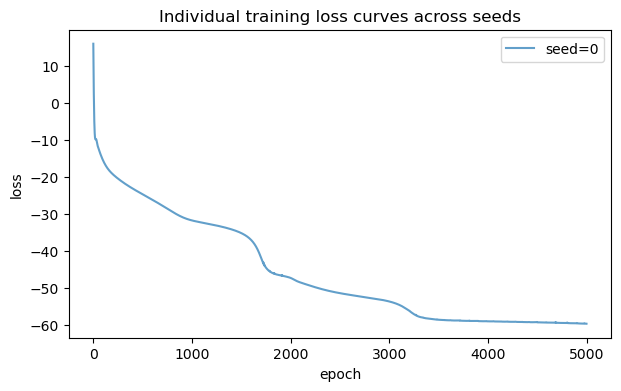

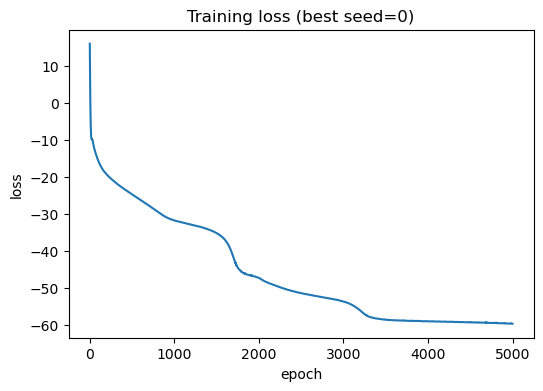

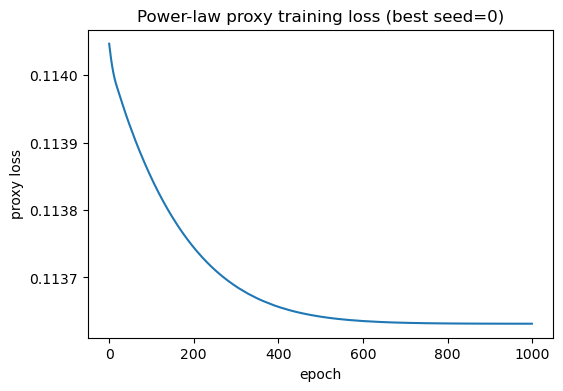

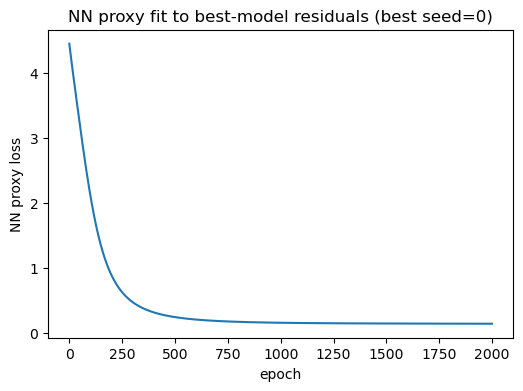

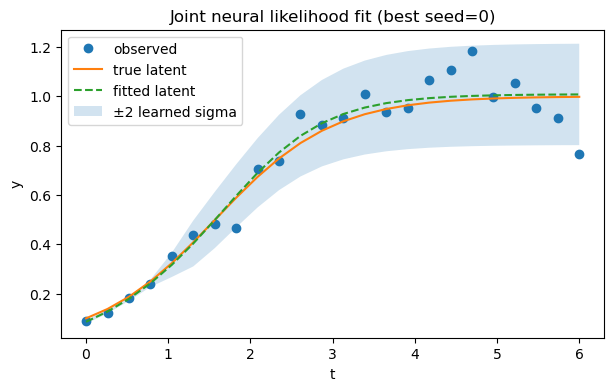

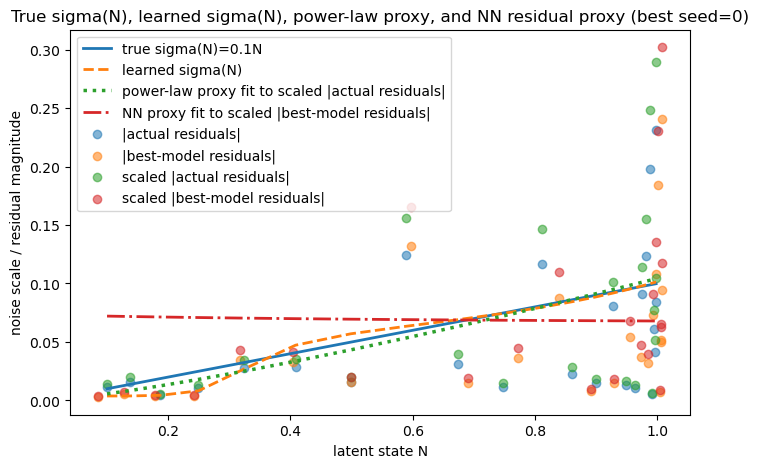

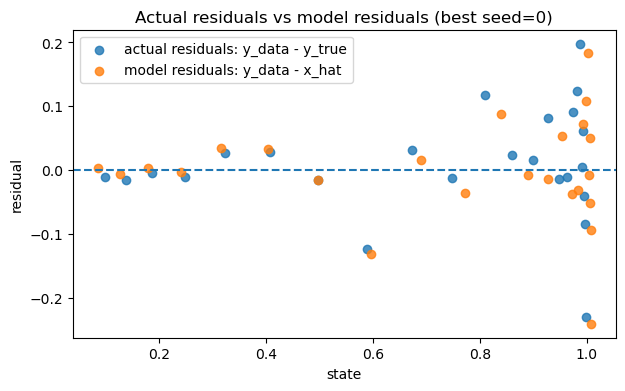

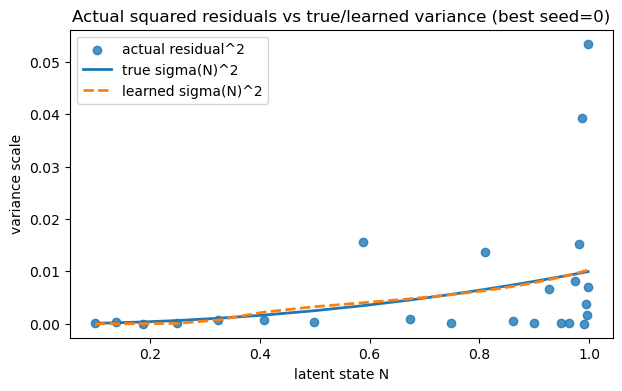

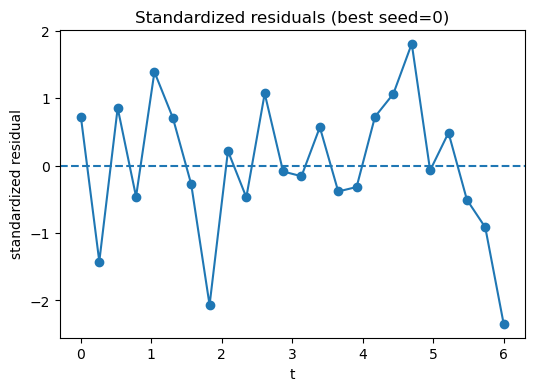

In [76]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.4
N0 = 0.1
numpts = 4 * (24 // 4)

t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data
#    Noise law is heteroscedastic: sigma_true(N) = 0.1 N
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)

torch.manual_seed(0)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true


# ============================================================
# 3. Neural RHS model: x' = f_theta(x)
# ============================================================
class DriftNet(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, t, x):
        return self.net(x)


# ============================================================
# 4. Noise model: log sigma(x) = s_phi(x)
# ============================================================
class NoiseNet(nn.Module):
    def __init__(self, hidden=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        log_sigma = self.net(x)
        sigma = torch.exp(log_sigma)
        return sigma, log_sigma


# ============================================================
# 5. Power-law proxy: sigma_proxy(N) = a * N^b
# ============================================================
class PowerLawProxy(nn.Module):
    def __init__(self, a_init=0.1, b_init=1.0):
        super().__init__()

        a_init_u = np.log(np.exp(a_init) - 1.0) if a_init > 1e-8 else -10.0
        b_init_u = np.log(np.exp(b_init) - 1.0) if b_init > 1e-8 else -10.0

        self.a_unconstrained = nn.Parameter(torch.tensor([a_init_u], dtype=torch.float32))
        self.b_unconstrained = nn.Parameter(torch.tensor([b_init_u], dtype=torch.float32))

    def a(self):
        return torch.nn.functional.softplus(self.a_unconstrained) + 1e-8

    def b(self):
        return torch.nn.functional.softplus(self.b_unconstrained) + 1e-8

    def forward(self, x):
        x_safe = torch.where(x > 0.0, x, torch.full_like(x, 1e-8))
        return self.a() * (x_safe ** self.b())


# ============================================================
# 6. NN proxy for residual magnitude
# ============================================================
class ResidualProxyNet(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return torch.nn.functional.softplus(self.net(x))


# ============================================================
# 7. Full joint model
# ============================================================
class JointNeuralLikelihoodModel(nn.Module):
    def __init__(self, hidden_drift=32, hidden_noise=16, x0_init=0.05):
        super().__init__()
        self.drift = DriftNet(hidden=hidden_drift)
        self.noise = NoiseNet(hidden=hidden_noise)
        self.x0_unconstrained = nn.Parameter(torch.tensor([[x0_init]], dtype=torch.float32))

    def x0(self):
        return torch.nn.functional.softplus(self.x0_unconstrained)

    def latent_traj(self, t):
        x0 = self.x0()
        x_path = odeint_rk4(self.drift, x0, t.squeeze()).squeeze(1)
        return x_path

    def nll(self, t, y_obs):
        x_path = self.latent_traj(t)
        sigma, log_sigma = self.noise(x_path)

        resid = y_obs - x_path
        nll_pointwise = 0.5 * (resid / sigma) ** 2 + log_sigma
        nll = nll_pointwise.sum()

        return nll, {
            "x_path": x_path,
            "sigma": sigma,
            "log_sigma": log_sigma,
            "resid": resid,
            "nll_pointwise": nll_pointwise,
        }


# ============================================================
# 8. Regularization helpers
# ============================================================
def smoothness_penalty_on_path(x_path):
    if len(x_path) < 3:
        return torch.tensor(0.0, device=x_path.device)
    second_diff = x_path[2:] - 2.0 * x_path[1:-1] + x_path[:-2]
    return (second_diff ** 2).sum()

def weight_decay(model):
    reg = 0.0
    for p in model.parameters():
        reg = reg + (p ** 2).sum()
    return reg

def monotonicity_penalty_sigma(x_ref, sigma_ref):
    x_flat = x_ref.squeeze(-1)
    sigma_flat = sigma_ref.squeeze(-1)

    idx = torch.argsort(x_flat)
    sigma_sorted = sigma_flat[idx]
    dsigma = sigma_sorted[1:] - sigma_sorted[:-1]
    return torch.relu(-dsigma).sum()

def sigma_anchor_penalty(sigma):
    return ((sigma - sigma.mean()) ** 2).sum()


# ============================================================
# 9. Train + evaluate one run
# ============================================================
def train_and_evaluate(
    seed,
    max_epochs_model=5000,
    max_epochs_proxy=1000,
    spike_factor=10.0,
    patience_after_best=200,
    grad_norm_spike_threshold=1e4,
    x_path_abs_threshold=10.0,
    sigma_abs_threshold=10.0,
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    y_obs = y_data.detach().clone()

    model = JointNeuralLikelihoodModel(
        hidden_drift=8,
        hidden_noise=4,
        x0_init=0.08
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    loss_history = []
    best_state = None
    best_loss = float("inf")
    terminated_early = False
    termination_reason = "completed"
    best_epoch = -1

    for epoch in range(max_epochs_model):
        optimizer.zero_grad()

        nll, aux = model.nll(t_obs, y_obs)
        x_path = aux["x_path"]
        sigma = aux["sigma"]

        # reg_path = 1e-2 * smoothness_penalty_on_path(x_path)
        # reg_w = 1e-6 * weight_decay(model)
        # reg_sigma = 1e-4 * sigma_anchor_penalty(sigma)
        reg_mono = 1.0 * monotonicity_penalty_sigma(x_path.detach(), sigma)

        loss = nll + reg_mono

        if not torch.isfinite(loss):
            terminated_early = True
            termination_reason = f"non-finite loss at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if not torch.isfinite(x_path).all():
            terminated_early = True
            termination_reason = f"non-finite latent trajectory at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if not torch.isfinite(sigma).all():
            terminated_early = True
            termination_reason = f"non-finite sigma at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        max_abs_x = x_path.abs().max().item()
        max_sigma = sigma.max().item()

        if max_abs_x > x_path_abs_threshold:
            terminated_early = True
            termination_reason = (
                f"latent trajectory exceeded threshold at epoch {epoch} "
                f"(max |x| = {max_abs_x:.6f})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if max_sigma > sigma_abs_threshold:
            terminated_early = True
            termination_reason = (
                f"sigma exceeded threshold at epoch {epoch} "
                f"(max sigma = {max_sigma:.6f})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        loss.backward()

        total_grad_sq = 0.0
        grad_is_finite = True
        for p in model.parameters():
            if p.grad is not None:
                if not torch.isfinite(p.grad).all():
                    grad_is_finite = False
                    break
                total_grad_sq += (p.grad ** 2).sum().item()

        grad_norm = np.sqrt(total_grad_sq) if grad_is_finite else np.inf

        if not np.isfinite(grad_norm):
            terminated_early = True
            termination_reason = f"non-finite gradient norm at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if grad_norm > grad_norm_spike_threshold:
            terminated_early = True
            termination_reason = (
                f"gradient spike at epoch {epoch} "
                f"(grad_norm = {grad_norm:.6e})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        current_loss = loss.item()
        loss_history.append(current_loss)

        if current_loss < best_loss:
            best_loss = current_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        elif best_loss < float("inf") and current_loss > best_loss + spike_factor:
            print("best loss", best_loss)
            print("spike threshold", best_loss + spike_factor)

            terminated_early = True
            termination_reason = (
                f"loss spike at epoch {epoch} "
                f"(loss = {current_loss:.6e}, best_loss = {best_loss:.6e})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if best_epoch >= 0 and (epoch - best_epoch) > patience_after_best:
            if current_loss > best_loss + 5.0 * max(abs(best_loss), 1.0):
                terminated_early = True
                termination_reason = (
                    f"sustained deterioration after best epoch "
                    f"(epoch = {epoch}, best_epoch = {best_epoch}, "
                    f"loss = {current_loss:.6e}, best_loss = {best_loss:.6e})"
                )
                print(f"[seed={seed}] Terminating: {termination_reason}")
                break

        optimizer.step()

        if epoch % 500 == 0:
            print(
                f"[seed={seed}] "
                f"epoch={epoch:5d} "
                f"loss={loss.item():.6f} "
                f"nll={nll.item():.6f} "
                f"mono={reg_mono.item():.6f} "
                f"x0={model.x0().item():.4f}"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    # ============================================================
    # 10. Fit power-law proxy to true residuals
    # ============================================================
    with torch.no_grad():
        actual_resid = y_data - y_true
        actual_abs_resid = actual_resid.abs()
        scaled_abs_resid = actual_abs_resid * np.sqrt(np.pi / 2.0)

    proxy_model = PowerLawProxy(a_init=0.1, b_init=1.0).to(device)
    proxy_optim = torch.optim.Adam(proxy_model.parameters(), lr=1e-3)

    proxy_loss_history = []
    best_proxy_state = None
    best_proxy_loss = float("inf")

    for epoch in range(max_epochs_proxy):
        proxy_optim.zero_grad()

        pred_scaled_abs_resid = proxy_model(y_true)

        proxy_data_loss = ((pred_scaled_abs_resid - scaled_abs_resid) ** 2).sum()
        proxy_reg = 1e-6 * (
            (proxy_model.a_unconstrained ** 2).sum() +
            (proxy_model.b_unconstrained ** 2).sum()
        )
        proxy_mono = 1.0 * monotonicity_penalty_sigma(y_true, pred_scaled_abs_resid)

        loss = proxy_data_loss + proxy_reg + proxy_mono
        loss.backward()
        proxy_optim.step()

        proxy_loss_history.append(loss.item())

        if loss.item() < best_proxy_loss:
            best_proxy_loss = loss.item()
            best_proxy_state = copy.deepcopy(proxy_model.state_dict())

    if best_proxy_state is not None:
        proxy_model.load_state_dict(best_proxy_state)

    # ============================================================
    # 11. Evaluate fitted objects
    # ============================================================
    with torch.no_grad():
        nll, aux = model.nll(t_obs, y_obs)

        x_hat = aux["x_path"]
        sigma_hat = aux["sigma"]
        resid = aux["resid"]
        z_hat = resid / sigma_hat

        sigma_true_vals = 0.1 * y_true
        sigma_hat_on_true, _ = model.noise(y_true)
        proxy_sigma_on_true = proxy_model(y_true)

        idx_true = torch.argsort(y_true.squeeze())
        N_true_sorted = y_true[idx_true].squeeze()
        sigma_true_sorted = sigma_true_vals[idx_true].squeeze()
        sigma_hat_true_sorted = sigma_hat_on_true[idx_true].squeeze()
        proxy_sigma_sorted = proxy_sigma_on_true[idx_true].squeeze()
        actual_abs_resid_sorted = actual_abs_resid[idx_true].squeeze()
        scaled_abs_resid_sorted = scaled_abs_resid[idx_true].squeeze()

    return {
        "seed": seed,
        "model": model,
        "proxy_model": proxy_model,
        "loss_history": loss_history,
        "proxy_loss_history": proxy_loss_history,
        "x_hat": x_hat.detach().clone(),
        "sigma_hat": sigma_hat.detach().clone(),
        "resid": resid.detach().clone(),
        "z_hat": z_hat.detach().clone(),
        "sigma_true_vals": sigma_true_vals.detach().clone(),
        "sigma_hat_on_true": sigma_hat_on_true.detach().clone(),
        "proxy_sigma_on_true": proxy_sigma_on_true.detach().clone(),
        "actual_resid": actual_resid.detach().clone(),
        "actual_abs_resid": actual_abs_resid.detach().clone(),
        "scaled_abs_resid": scaled_abs_resid.detach().clone(),
        "N_true_sorted": N_true_sorted.detach().clone(),
        "sigma_true_sorted": sigma_true_sorted.detach().clone(),
        "sigma_hat_true_sorted": sigma_hat_true_sorted.detach().clone(),
        "proxy_sigma_sorted": proxy_sigma_sorted.detach().clone(),
        "actual_abs_resid_sorted": actual_abs_resid_sorted.detach().clone(),
        "scaled_abs_resid_sorted": scaled_abs_resid_sorted.detach().clone(),
        "proxy_a": proxy_model.a().item(),
        "proxy_b": proxy_model.b().item(),
        "terminated_early": terminated_early,
        "termination_reason": termination_reason,
        "best_loss": best_loss,
        "best_epoch": best_epoch,
    }


# ============================================================
# 12. Run over multiple initializations
# ============================================================
num_runs = 1
results = []

for seed in range(num_runs):
    print("\n===============================")
    print(f"Running initialization {seed}")
    print("===============================\n")

    res = train_and_evaluate(seed)
    results.append(res)

    print(
        f"[seed={seed}] fitted power-law proxy: "
        f"sigma_proxy(N) = {res['proxy_a']:.6f} * N^{res['proxy_b']:.6f}"
    )
    print(
        f"[seed={seed}] status: "
        f"terminated_early={res['terminated_early']} "
        f"reason={res['termination_reason']}"
    )

valid_results = [r for r in results if len(r["loss_history"]) > 0]

if len(valid_results) == 0:
    raise RuntimeError("No valid runs completed any optimization steps.")

best_run_idx = int(np.argmin([r["best_loss"] for r in valid_results]))
best_res = valid_results[best_run_idx]

print("\n==========================================")
print(
    f"Best run is seed={best_res['seed']} "
    f"with best_loss={best_res['best_loss']:.6f} "
    f"at best_epoch={best_res['best_epoch']}"
)
print("==========================================\n")


# ============================================================
# 13. Fit NN proxy to residuals from best-fit model wrt data
#     Use scaled |model residual| so target is comparable to sigma
# ============================================================
with torch.no_grad():
    best_model_resid = best_res["resid"]
    best_model_abs_resid = best_model_resid.abs()
    best_model_scaled_abs_resid = best_model_abs_resid * np.sqrt(np.pi / 2.0)

    # Fit as a function of best-fit latent trajectory x_hat
    x_proxy_input = best_res["x_hat"].detach().clone()

resid_nn_proxy = ResidualProxyNet(hidden=4).to(device)
resid_nn_proxy_optim = torch.optim.Adam(resid_nn_proxy.parameters(), lr=1e-3)

best_resid_nn_state = None
best_resid_nn_loss = float("inf")
resid_nn_proxy_loss_history = []

for epoch in range(2000):
    resid_nn_proxy_optim.zero_grad()

    pred_scaled_abs_resid_nn = resid_nn_proxy(x_proxy_input)

    resid_nn_data_loss = ((pred_scaled_abs_resid_nn - best_model_scaled_abs_resid) ** 2).sum()
    resid_nn_reg = 1e-6 * sum((p ** 2).sum() for p in resid_nn_proxy.parameters())
    resid_nn_mono = 1.0 * monotonicity_penalty_sigma(x_proxy_input, pred_scaled_abs_resid_nn)

    loss = resid_nn_data_loss + resid_nn_mono
    loss.backward()
    resid_nn_proxy_optim.step()

    resid_nn_proxy_loss_history.append(loss.item())

    if loss.item() < best_resid_nn_loss:
        best_resid_nn_loss = loss.item()
        best_resid_nn_state = copy.deepcopy(resid_nn_proxy.state_dict())

if best_resid_nn_state is not None:
    resid_nn_proxy.load_state_dict(best_resid_nn_state)

with torch.no_grad():
    # evaluate on y_true so it can be overlaid on the sigma(N) plot
    resid_nn_sigma_on_true = resid_nn_proxy(y_true)
    resid_nn_sigma_sorted = resid_nn_sigma_on_true[idx_true].squeeze()


# ============================================================
# 14. Retain only best-seed info
# ============================================================
loss_history = best_res["loss_history"]
proxy_loss_history = best_res["proxy_loss_history"]
x_hat = best_res["x_hat"]
sigma_hat = best_res["sigma_hat"]
resid = best_res["resid"]
z_hat = best_res["z_hat"]
sigma_true_vals = best_res["sigma_true_vals"]
actual_resid = best_res["actual_resid"]
actual_abs_resid = best_res["actual_abs_resid"]
scaled_abs_resid = best_res["scaled_abs_resid"]
N_true_sorted = best_res["N_true_sorted"]
sigma_true_sorted = best_res["sigma_true_sorted"]
sigma_hat_true_sorted = best_res["sigma_hat_true_sorted"]
proxy_sigma_sorted = best_res["proxy_sigma_sorted"]

idx_true = torch.argsort(y_true.squeeze())


# ============================================================
# 15. Plot diagnostics
# ============================================================

# Individual training loss curves across seeds
plt.figure(figsize=(7, 4))
for r in valid_results:
    plt.plot(r["loss_history"], alpha=0.7, linewidth=1.5, label=f"seed={r['seed']}")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Individual training loss curves across seeds")
plt.legend()
plt.show()

# Training loss: best run only
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title(f"Training loss (best seed={best_res['seed']})")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

# Power-law proxy training loss
plt.figure(figsize=(6, 4))
plt.plot(proxy_loss_history)
plt.xlabel("epoch")
plt.ylabel("proxy loss")
plt.title(f"Power-law proxy training loss (best seed={best_res['seed']})")
plt.show()

# NN proxy training loss for best-fit model residuals
plt.figure(figsize=(6, 4))
plt.plot(resid_nn_proxy_loss_history)
plt.xlabel("epoch")
plt.ylabel("NN proxy loss")
plt.title(f"NN proxy fit to best-model residuals (best seed={best_res['seed']})")
plt.show()

# Representative trajectory fit: best run only
plt.figure(figsize=(7, 4))
plt.plot(t_obs.cpu(), y_data.cpu(), "o", label="observed")
plt.plot(t_obs.cpu(), y_true.cpu(), "-", label="true latent")
plt.plot(t_obs.cpu(), x_hat.cpu(), "--", label="fitted latent")
plt.fill_between(
    t_obs.squeeze().cpu().numpy(),
    (x_hat - 2 * sigma_hat).squeeze().cpu().numpy(),
    (x_hat + 2 * sigma_hat).squeeze().cpu().numpy(),
    alpha=0.2,
    label="±2 learned sigma"
)
plt.legend()
plt.xlabel("t")
plt.ylabel("y")
plt.title(f"Joint neural likelihood fit (best seed={best_res['seed']})")
plt.show()

# Main sigma comparison plot: best run only
plt.figure(figsize=(8, 5))
plt.plot(
    N_true_sorted.cpu(),
    sigma_true_sorted.cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)=0.1N"
)
plt.plot(
    N_true_sorted.cpu(),
    sigma_hat_true_sorted.cpu(),
    "--",
    linewidth=2,
    label="learned sigma(N)"
)
plt.plot(
    N_true_sorted.cpu(),
    proxy_sigma_sorted.cpu(),
    ":",
    linewidth=2.5,
    label="power-law proxy fit to scaled |actual residuals|"
)
plt.plot(
    N_true_sorted.cpu(),
    resid_nn_sigma_sorted.cpu(),
    "-.",
    linewidth=2.0,
    label="NN proxy fit to scaled |best-model residuals|"
)
plt.scatter(
    y_true.squeeze().cpu(),
    actual_abs_resid.squeeze().cpu(),
    alpha=0.55,
    label="|actual residuals|"
)
plt.scatter(
    x_hat.squeeze().cpu(),
    best_model_abs_resid.squeeze().cpu(),
    alpha=0.55,
    label="|best-model residuals|"
)
plt.scatter(
    y_true.squeeze().cpu(),
    scaled_abs_resid.squeeze().cpu(),
    alpha=0.55,
    label="scaled |actual residuals|"
)
plt.scatter(
    x_hat.squeeze().cpu(),
    best_model_scaled_abs_resid.squeeze().cpu(),
    alpha=0.55,
    label="scaled |best-model residuals|"
)
plt.xlabel("latent state N")
plt.ylabel("noise scale / residual magnitude")
plt.title(
    f"True sigma(N), learned sigma(N), power-law proxy, and NN residual proxy "
    f"(best seed={best_res['seed']})"
)
plt.legend()
plt.show()

# Residuals: actual vs model residuals
plt.figure(figsize=(7, 4))
plt.axhline(0.0, linestyle="--")
plt.scatter(
    y_true.squeeze().cpu(),
    actual_resid.squeeze().cpu(),
    label="actual residuals: y_data - y_true",
    alpha=0.8
)
plt.scatter(
    x_hat.squeeze().cpu(),
    resid.squeeze().cpu(),
    label="model residuals: y_data - x_hat",
    alpha=0.8
)
plt.xlabel("state")
plt.ylabel("residual")
plt.title(f"Actual residuals vs model residuals (best seed={best_res['seed']})")
plt.legend()
plt.show()

# Squared residuals vs variance curves
plt.figure(figsize=(7, 4))
plt.scatter(
    y_true.squeeze().cpu(),
    (actual_resid ** 2).squeeze().cpu(),
    alpha=0.8,
    label="actual residual^2"
)
plt.plot(
    N_true_sorted.cpu(),
    (sigma_true_sorted ** 2).cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)^2"
)
plt.plot(
    N_true_sorted.cpu(),
    (sigma_hat_true_sorted ** 2).cpu(),
    "--",
    linewidth=2,
    label="learned sigma(N)^2"
)
plt.xlabel("latent state N")
plt.ylabel("variance scale")
plt.title(f"Actual squared residuals vs true/learned variance (best seed={best_res['seed']})")
plt.legend()
plt.show()

# Standardized residuals
plt.figure(figsize=(6, 4))
plt.plot(t_obs.cpu(), z_hat.cpu(), "o-")
plt.axhline(0.0, linestyle="--")
plt.xlabel("t")
plt.ylabel("standardized residual")
plt.title(f"Standardized residuals (best seed={best_res['seed']})")
plt.show()

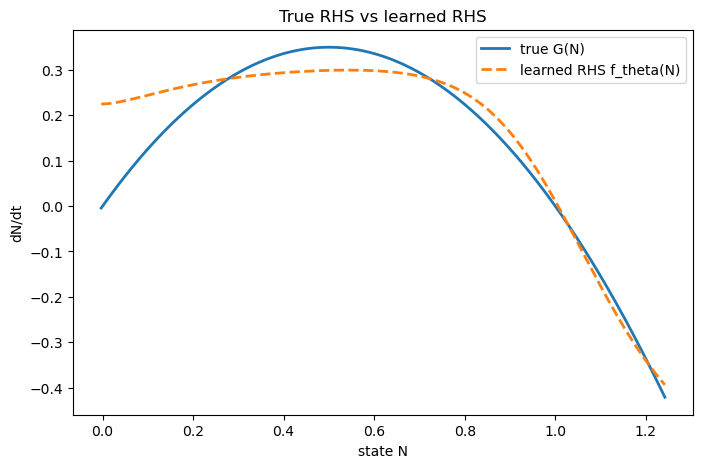

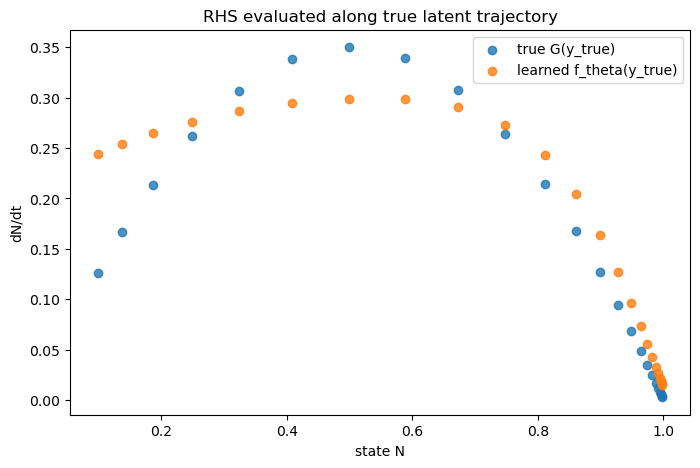

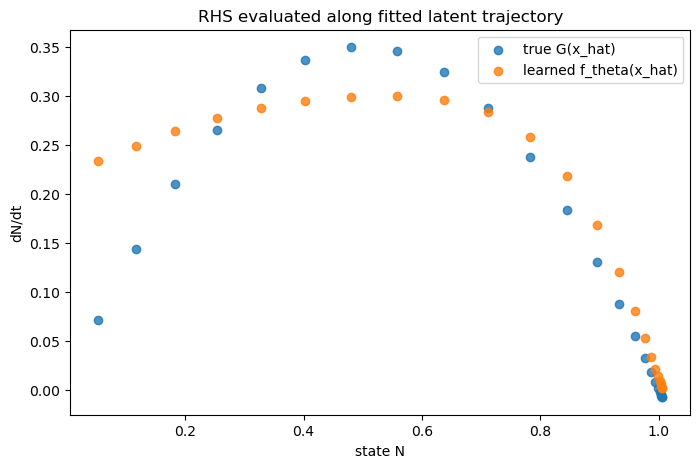

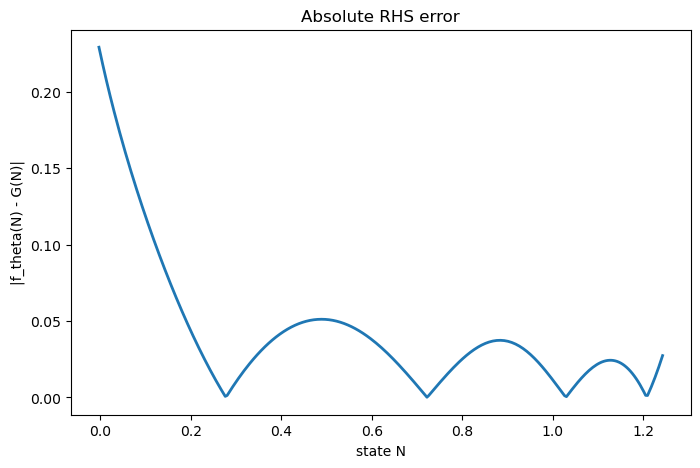

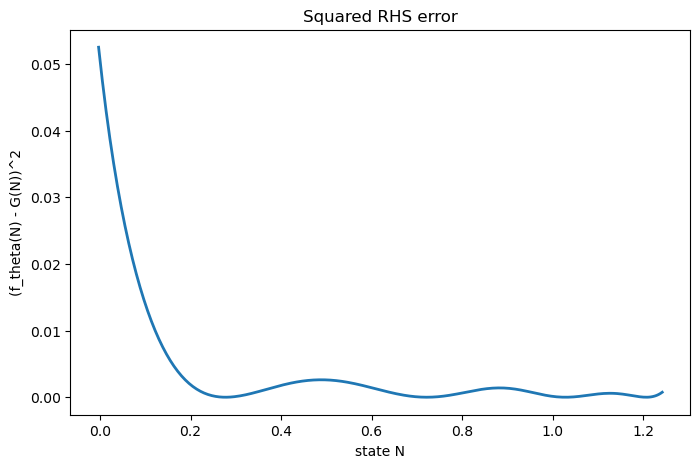

In [90]:
# ============================================================
# 12. Plot learned RHS against the true G(N)
# ============================================================
with torch.no_grad():
    # Choose a grid that covers the relevant state range
    n_min = min(y_true.min().item(), x_hat.min().item(), y_obs.min().item())
    n_max = max(y_true.max().item(), x_hat.max().item(), y_obs.max().item())

    pad = 0.05 * (n_max - n_min + 1e-6)
    N_grid = torch.linspace(n_min - pad, n_max + pad, 300, device=device).view(-1, 1)

    G_true_grid = G_true(N_grid)
    G_learned_grid = model.drift(torch.tensor(0.0, device=device), N_grid)

    # Also evaluate at the true latent states and fitted latent states
    G_true_on_y_true = G_true(y_true)
    G_learned_on_y_true = model.drift(torch.tensor(0.0, device=device), y_true)

    G_true_on_x_hat = G_true(x_hat)
    G_learned_on_x_hat = model.drift(torch.tensor(0.0, device=device), x_hat)

# Smooth curve comparison
plt.figure(figsize=(8, 5))
plt.plot(
    N_grid.cpu().numpy(),
    G_true_grid.cpu().numpy(),
    linewidth=2,
    label="true G(N)"
)
plt.plot(
    N_grid.cpu().numpy(),
    G_learned_grid.cpu().numpy(),
    "--",
    linewidth=2,
    label="learned RHS f_theta(N)"
)
plt.xlabel("state N")
plt.ylabel("dN/dt")
plt.title("True RHS vs learned RHS")
plt.legend()
plt.show()

# Comparison at observed trajectory states
plt.figure(figsize=(8, 5))
plt.scatter(
    y_true.squeeze().cpu().numpy(),
    G_true_on_y_true.squeeze().cpu().numpy(),
    alpha=0.8,
    label="true G(y_true)"
)
plt.scatter(
    y_true.squeeze().cpu().numpy(),
    G_learned_on_y_true.squeeze().cpu().numpy(),
    alpha=0.8,
    label="learned f_theta(y_true)"
)
plt.xlabel("state N")
plt.ylabel("dN/dt")
plt.title("RHS evaluated along true latent trajectory")
plt.legend()
plt.show()

# Comparison at fitted latent states
plt.figure(figsize=(8, 5))
plt.scatter(
    x_hat.squeeze().cpu().numpy(),
    G_true_on_x_hat.squeeze().cpu().numpy(),
    alpha=0.8,
    label="true G(x_hat)"
)
plt.scatter(
    x_hat.squeeze().cpu().numpy(),
    G_learned_on_x_hat.squeeze().cpu().numpy(),
    alpha=0.8,
    label="learned f_theta(x_hat)"
)
plt.xlabel("state N")
plt.ylabel("dN/dt")
plt.title("RHS evaluated along fitted latent trajectory")
plt.legend()
plt.show()

# Pointwise error on the grid
with torch.no_grad():
    rhs_abs_err = (G_learned_grid - G_true_grid).abs()
    rhs_sq_err = (G_learned_grid - G_true_grid) ** 2

plt.figure(figsize=(8, 5))
plt.plot(
    N_grid.cpu().numpy(),
    rhs_abs_err.cpu().numpy(),
    linewidth=2
)
plt.xlabel("state N")
plt.ylabel("|f_theta(N) - G(N)|")
plt.title("Absolute RHS error")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    N_grid.cpu().numpy(),
    rhs_sq_err.cpu().numpy(),
    linewidth=2
)
plt.xlabel("state N")
plt.ylabel("(f_theta(N) - G(N))^2")
plt.title("Squared RHS error")
plt.show()

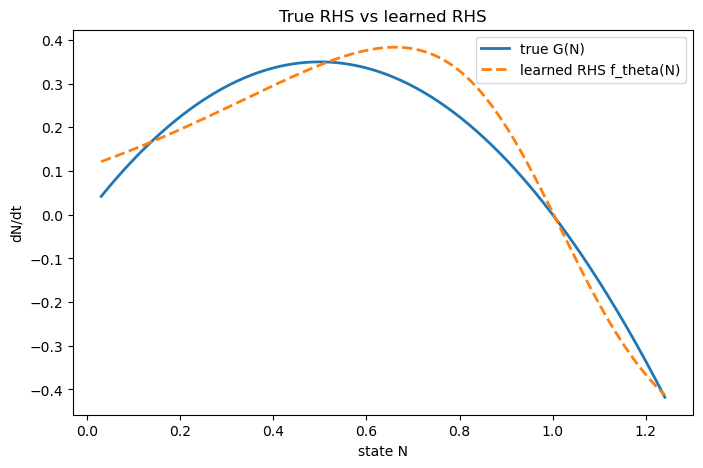

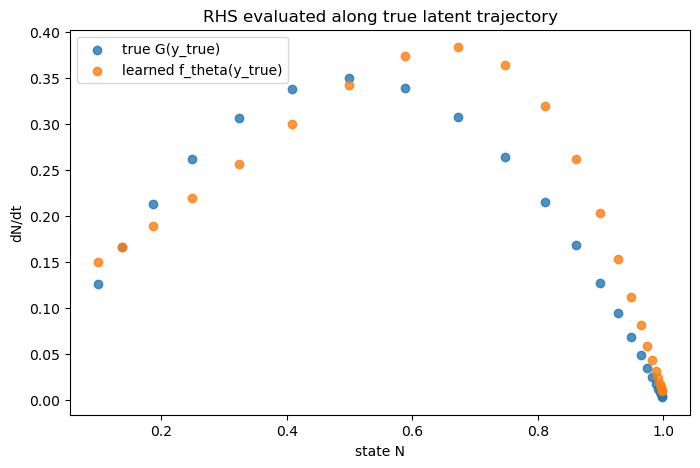

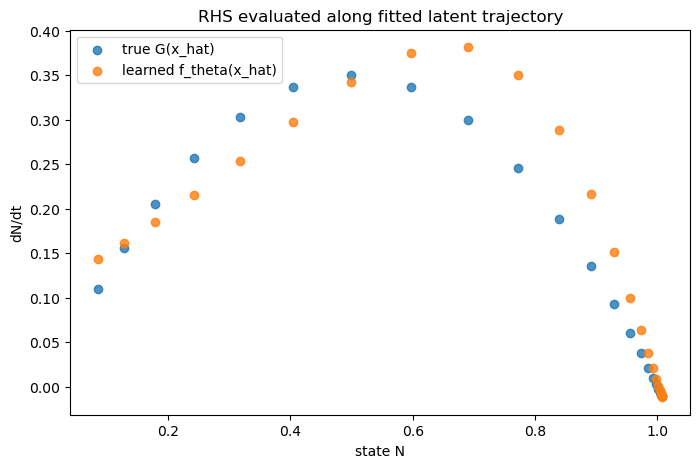

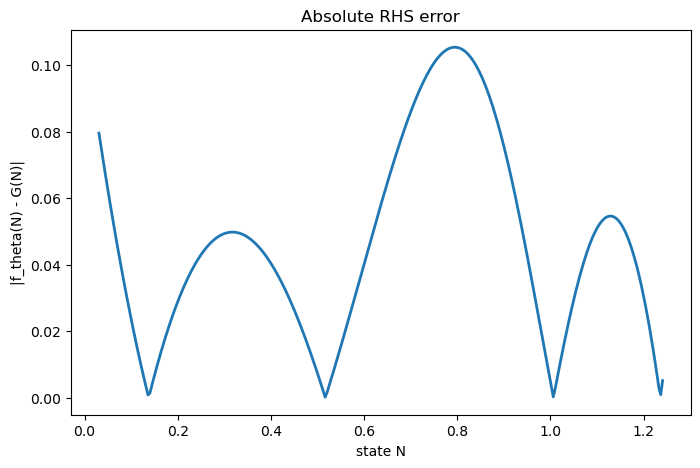

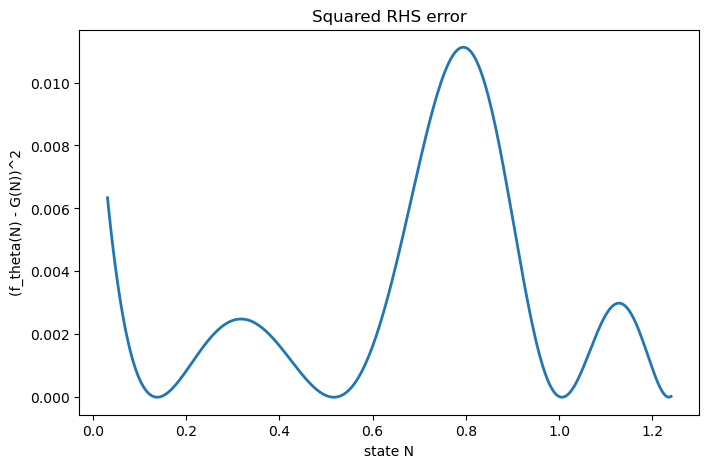

Residual-fit sigma(N): 0.104340 * N^1.265414

Running initialization 123

[seed=123] epoch=    0 loss=590.376892 nll=590.376892 mono=0.000000 x0=0.7314 a=0.2009 b=0.0000
[seed=123] epoch=  500 loss=-27.784115 nll=-27.784115 mono=0.000000 x0=0.4131 a=0.2159 b=0.0000
[seed=123] epoch= 1000 loss=-34.515442 nll=-34.515442 mono=0.000000 x0=0.2424 a=0.1620 b=0.0000
[seed=123] epoch= 1500 loss=-40.483780 nll=-40.483780 mono=0.000000 x0=0.1345 a=0.1204 b=0.0001
[seed=123] epoch= 2000 loss=-48.975273 nll=-48.975273 mono=0.000000 x0=0.0979 a=0.0804 b=0.0006
[seed=123] epoch= 2500 loss=-57.076351 nll=-57.076351 mono=0.000000 x0=0.0850 a=0.0985 b=1.1697
[seed=123] fitted sigma(N): 0.104145 * N^1.264115
[seed=123] status: terminated_early=False reason=completed

Running initialization 124

[seed=124] epoch=    0 loss=645.049805 nll=645.049805 mono=0.000000 x0=0.7366 a=0.2009 b=0.0000
[seed=124] epoch=  500 loss=-28.181927 nll=-28.181927 mono=0.000000 x0=0.4018 a=0.2182 b=0.0000
[seed=124] epoch= 10

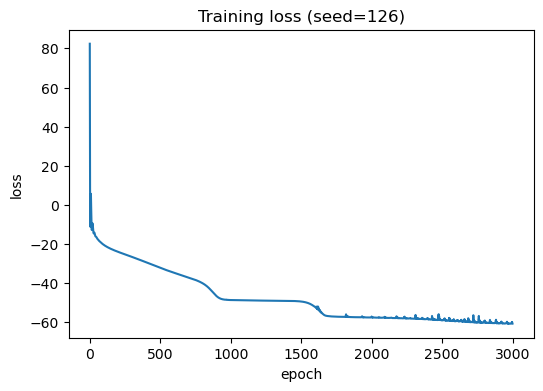

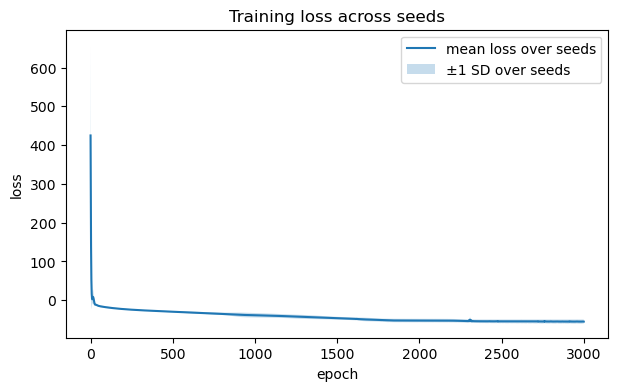

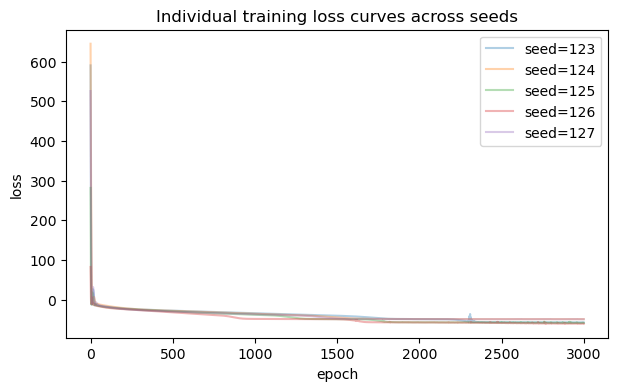

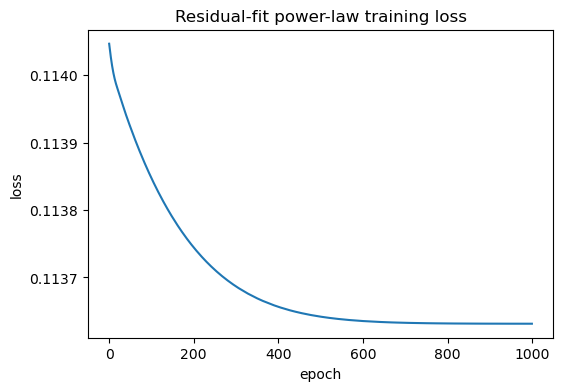

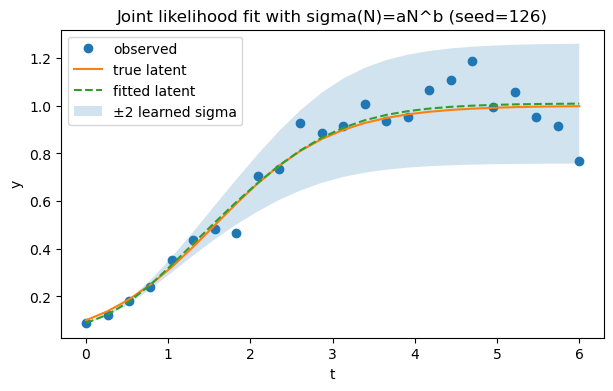

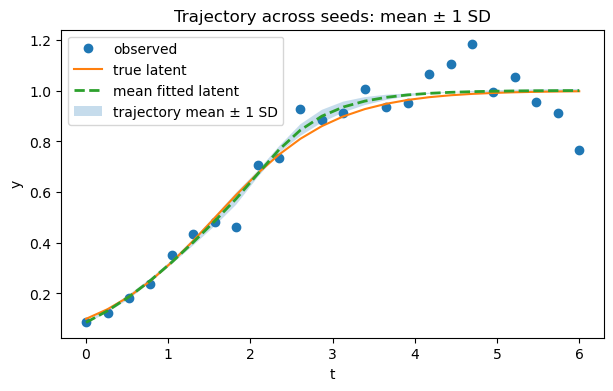

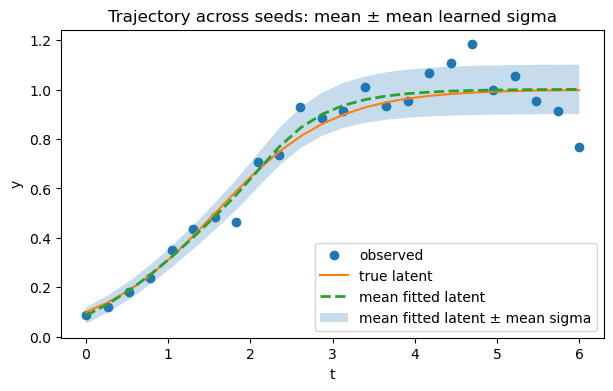

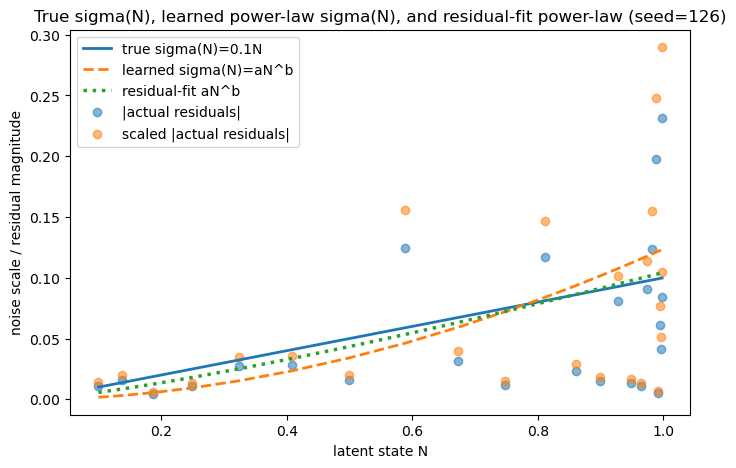

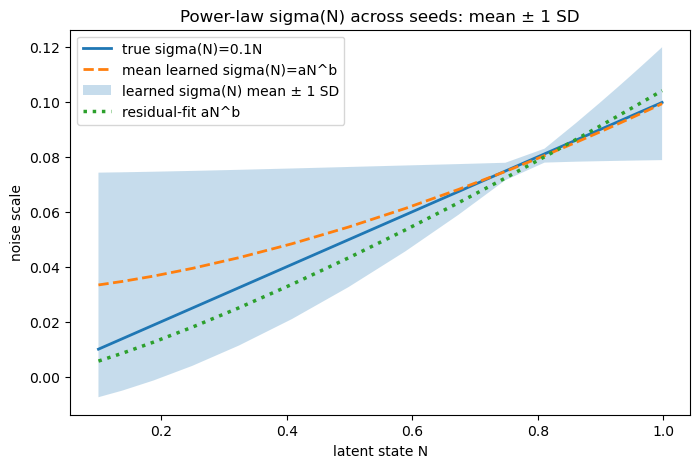

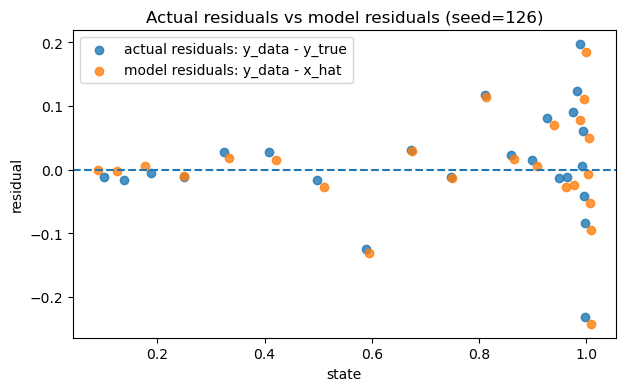

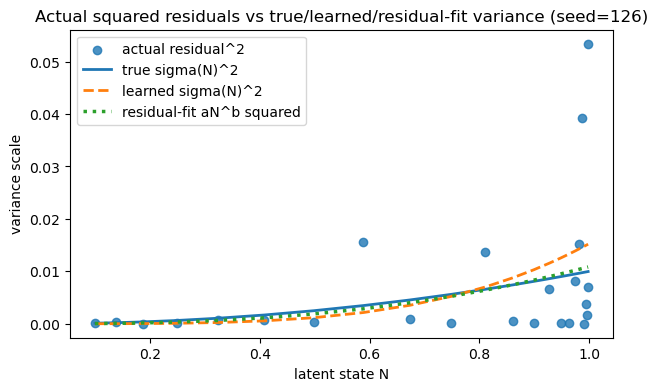

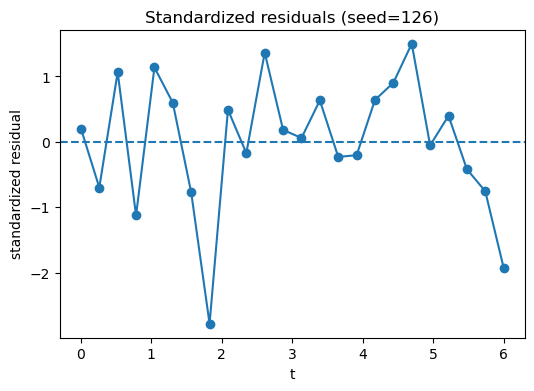

In [ ]:
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ============================================================
# Reproducibility / device
# ============================================================
torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cpu")


# ============================================================
# 1. Ground-truth system: logistic growth dN/dt = r N (1 - N)
# ============================================================
r_true = 1.4
N0 = 0.1
numpts = 4 * (24 // 4)

t_obs = torch.linspace(0.0, 6.0, numpts, device=device).view(-1, 1)

def G_true(N):
    return r_true * N * (1.0 - N)


# ============================================================
# 2. Generate synthetic observed data
#    Noise law is heteroscedastic: sigma_true(N) = 0.1 N
# ============================================================
def rk4_step(f, y, t, dt):
    k1 = f(t, y)
    k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1)
    k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2)
    k4 = f(t + dt, y + dt * k3)
    return y + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

def odeint_rk4(f, y0, t):
    ys = [y0]
    y = y0
    for i in range(len(t) - 1):
        ti = t[i]
        dt = t[i + 1] - t[i]
        y = rk4_step(f, y, ti, dt)
        ys.append(y)
    return torch.stack(ys, dim=0)

with torch.no_grad():
    y0_true = torch.tensor([[N0]], dtype=torch.float32, device=device)
    y_true = odeint_rk4(lambda t, y: G_true(y), y0_true, t_obs.squeeze()).squeeze(1)

torch.manual_seed(0)
y_data = y_true + 0.1 * torch.randn_like(y_true) * y_true


# ============================================================
# 3. Neural RHS model: x' = f_theta(x)
# ============================================================
class DriftNet(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, t, x):
        return self.net(x)


# ============================================================
# 4. Parametric power-law model: sigma(x) = a * x^b
#    Used both for learned sigma(N) and residual-fit sigma(N)
# ============================================================
class PowerLawSigma(nn.Module):
    def __init__(self, a_init=0.1, b_init=1.0):
        super().__init__()

        a_init_u = np.log(np.exp(a_init) - 1.0) if a_init > 1e-8 else -10.0
        b_init_u = np.log(np.exp(b_init) - 1.0) if b_init > 1e-8 else -10.0

        self.a_unconstrained = nn.Parameter(torch.tensor([a_init_u], dtype=torch.float32))
        self.b_unconstrained = nn.Parameter(torch.tensor([b_init_u], dtype=torch.float32))

    def a(self):
        return torch.nn.functional.softplus(self.a_unconstrained) + 1e-8

    def b(self):
        return torch.nn.functional.softplus(self.b_unconstrained) + 1e-8

    def sigma_only(self, x):
        x_safe = torch.where(x > 0.0, x, torch.full_like(x, 1e-8))
        return self.a() * (x_safe ** self.b())

    def forward(self, x):
        sigma = self.sigma_only(x)
        log_sigma = torch.log(sigma)
        return sigma, log_sigma


# ============================================================
# 5. Full joint model with power-law sigma
# ============================================================
class JointNeuralLikelihoodModel(nn.Module):
    def __init__(self, hidden_drift=32, x0_init=0.05, sigma_a_init=0.1, sigma_b_init=1.0):
        super().__init__()
        self.drift = DriftNet(hidden=hidden_drift)
        self.noise = PowerLawSigma(a_init=sigma_a_init, b_init=sigma_b_init)
        self.x0_unconstrained = nn.Parameter(torch.tensor([[x0_init]], dtype=torch.float32))

    def x0(self):
        return torch.nn.functional.softplus(self.x0_unconstrained)

    def latent_traj(self, t):
        x0 = self.x0()
        x_path = odeint_rk4(self.drift, x0, t.squeeze()).squeeze(1)
        return x_path

    def nll(self, t, y_obs):
        x_path = self.latent_traj(t)
        sigma, log_sigma = self.noise(x_path)

        resid = y_obs - x_path
        nll_pointwise = 0.5 * (resid / sigma) ** 2 + log_sigma
        nll = nll_pointwise.sum()

        return nll, {
            "x_path": x_path,
            "sigma": sigma,
            "log_sigma": log_sigma,
            "resid": resid,
            "nll_pointwise": nll_pointwise,
        }


# ============================================================
# 6. Regularization helpers
# ============================================================
def smoothness_penalty_on_path(x_path):
    if len(x_path) < 3:
        return torch.tensor(0.0, device=x_path.device)
    second_diff = x_path[2:] - 2.0 * x_path[1:-1] + x_path[:-2]
    return (second_diff ** 2).sum()

def weight_decay(model):
    reg = 0.0
    for p in model.parameters():
        reg = reg + (p ** 2).sum()
    return reg

def monotonicity_penalty_sigma(x_ref, sigma_ref):
    x_flat = x_ref.squeeze(-1)
    sigma_flat = sigma_ref.squeeze(-1)

    idx = torch.argsort(x_flat)
    sigma_sorted = sigma_flat[idx]
    dsigma = sigma_sorted[1:] - sigma_sorted[:-1]
    return torch.relu(-dsigma).sum()

def sigma_anchor_penalty(sigma):
    return ((sigma - sigma.mean()) ** 2).sum()


# ============================================================
# 7. Fit power-law to true residual magnitudes
#    We fit to scaled |residual| so target is comparable to sigma
#    under a Gaussian law: E|Z| = sqrt(2/pi)
# ============================================================
def fit_residual_powerlaw(
    x_ref,
    scaled_abs_resid,
    max_epochs=4000,
    lr=1e-2,
    a_init=0.1,
    b_init=1.0,
):
    proxy_model = PowerLawSigma(a_init=a_init, b_init=b_init).to(device)
    optimizer = torch.optim.Adam(proxy_model.parameters(), lr=lr)

    best_state = None
    best_loss = float("inf")
    loss_history = []

    for epoch in range(max_epochs):
        optimizer.zero_grad()

        pred = proxy_model.sigma_only(x_ref)
        data_loss = ((pred - scaled_abs_resid) ** 2).sum()
        reg = 1e-6 * (
            (proxy_model.a_unconstrained ** 2).sum()
            + (proxy_model.b_unconstrained ** 2).sum()
        )
        mono = 1.0 * monotonicity_penalty_sigma(x_ref, pred)

        loss = data_loss + reg + mono
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        if loss.item() < best_loss:
            best_loss = loss.item()
            best_state = copy.deepcopy(proxy_model.state_dict())

    if best_state is not None:
        proxy_model.load_state_dict(best_state)

    return proxy_model, loss_history


# ============================================================
# 8. Train + evaluate one run
# ============================================================
def train_and_evaluate(
    seed,
    residual_proxy_model,
    max_epochs_model=3000,
    spike_delta_abs=10.0,
    spike_delta_rel=5.0,
    patience_after_best=200,
    grad_norm_spike_threshold=1e6,
    x_path_abs_threshold=10.0,
    sigma_abs_threshold=10.0,
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    y_obs = y_data.detach().clone()

    model = JointNeuralLikelihoodModel(
        hidden_drift=8,
        x0_init=0.08,
        sigma_a_init=0.2,
        sigma_b_init=0.0,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)

    loss_history = []
    best_state = None
    best_loss = float("inf")
    terminated_early = False
    termination_reason = "completed"
    best_epoch = -1

    for epoch in range(max_epochs_model):
        optimizer.zero_grad()

        nll, aux = model.nll(t_obs, y_obs)
        x_path = aux["x_path"]
        sigma = aux["sigma"]

        # Optional regularizers
        # reg_path = 1e-2 * smoothness_penalty_on_path(x_path)
        # reg_w = 1e-6 * weight_decay(model)
        # reg_sigma = 1e-4 * sigma_anchor_penalty(sigma)
        reg_mono = 1.0 * monotonicity_penalty_sigma(x_path.detach(), sigma)

        loss = nll + reg_mono

        if not torch.isfinite(loss):
            terminated_early = True
            termination_reason = f"non-finite loss at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if not torch.isfinite(x_path).all():
            terminated_early = True
            termination_reason = f"non-finite latent trajectory at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if not torch.isfinite(sigma).all():
            terminated_early = True
            termination_reason = f"non-finite sigma at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        max_abs_x = x_path.abs().max().item()
        max_sigma = sigma.max().item()

        if max_abs_x > x_path_abs_threshold:
            terminated_early = True
            termination_reason = (
                f"latent trajectory exceeded threshold at epoch {epoch} "
                f"(max |x| = {max_abs_x:.6f})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if max_sigma > sigma_abs_threshold:
            terminated_early = True
            termination_reason = (
                f"sigma exceeded threshold at epoch {epoch} "
                f"(max sigma = {max_sigma:.6f})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        loss.backward()

        total_grad_sq = 0.0
        grad_is_finite = True
        for p in model.parameters():
            if p.grad is not None:
                if not torch.isfinite(p.grad).all():
                    grad_is_finite = False
                    break
                total_grad_sq += (p.grad ** 2).sum().item()

        grad_norm = np.sqrt(total_grad_sq) if grad_is_finite else np.inf

        if not np.isfinite(grad_norm):
            terminated_early = True
            termination_reason = f"non-finite gradient norm at epoch {epoch}"
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        if grad_norm > grad_norm_spike_threshold:
            terminated_early = True
            termination_reason = (
                f"gradient spike at epoch {epoch} "
                f"(grad_norm = {grad_norm:.6e})"
            )
            print(f"[seed={seed}] Terminating: {termination_reason}")
            break

        current_loss = loss.item()
        loss_history.append(current_loss)

        if current_loss < best_loss:
            best_loss = current_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        elif best_loss < float("inf"):
            loss_jump = current_loss - best_loss
            relative_jump = loss_jump / max(abs(best_loss), 1.0)

            if loss_jump > spike_delta_abs and relative_jump > spike_delta_rel:
                print("best loss", best_loss)
                print("loss jump", loss_jump)
                print("relative jump", relative_jump)

                terminated_early = True
                termination_reason = (
                    f"loss spike at epoch {epoch} "
                    f"(loss = {current_loss:.6e}, best_loss = {best_loss:.6e}, "
                    f"jump = {loss_jump:.6e}, rel_jump = {relative_jump:.6e})"
                )
                print(f"[seed={seed}] Terminating: {termination_reason}")
                break

        if best_epoch >= 0 and (epoch - best_epoch) > patience_after_best:
            if current_loss > best_loss + 5.0 * max(abs(best_loss), 1.0):
                terminated_early = True
                termination_reason = (
                    f"sustained deterioration after best epoch "
                    f"(epoch = {epoch}, best_epoch = {best_epoch}, "
                    f"loss = {current_loss:.6e}, best_loss = {best_loss:.6e})"
                )
                print(f"[seed={seed}] Terminating: {termination_reason}")
                break

        optimizer.step()

        if epoch % 500 == 0:
            print(
                f"[seed={seed}] "
                f"epoch={epoch:5d} "
                f"loss={loss.item():.6f} "
                f"nll={nll.item():.6f} "
                f"mono={reg_mono.item():.6f} "
                f"x0={model.x0().item():.4f} "
                f"a={model.noise.a().item():.4f} "
                f"b={model.noise.b().item():.4f}"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    # ============================================================
    # 9. Evaluate fitted objects
    # ============================================================
    with torch.no_grad():
        nll, aux = model.nll(t_obs, y_obs)

        x_hat = aux["x_path"]
        sigma_hat = aux["sigma"]
        resid = aux["resid"]
        z_hat = resid / sigma_hat

        sigma_true_vals = 0.1 * y_true
        sigma_hat_on_true, _ = model.noise(y_true)
        residual_fit_sigma_on_true = residual_proxy_model(y_true)[0]

        idx_true = torch.argsort(y_true.squeeze())
        N_true_sorted = y_true[idx_true].squeeze()
        sigma_true_sorted = sigma_true_vals[idx_true].squeeze()
        sigma_hat_true_sorted = sigma_hat_on_true[idx_true].squeeze()
        residual_fit_sigma_sorted = residual_fit_sigma_on_true[idx_true].squeeze()

        actual_resid = y_data - y_true
        actual_abs_resid = actual_resid.abs()
        scaled_abs_resid = actual_abs_resid * np.sqrt(np.pi / 2.0)
        actual_abs_resid_sorted = actual_abs_resid[idx_true].squeeze()
        scaled_abs_resid_sorted = scaled_abs_resid[idx_true].squeeze()

    return {
        "seed": seed,
        "model": model,
        "loss_history": loss_history,
        "x_hat": x_hat.detach().clone(),
        "sigma_hat": sigma_hat.detach().clone(),
        "resid": resid.detach().clone(),
        "z_hat": z_hat.detach().clone(),
        "sigma_true_vals": sigma_true_vals.detach().clone(),
        "sigma_hat_on_true": sigma_hat_on_true.detach().clone(),
        "residual_fit_sigma_on_true": residual_fit_sigma_on_true.detach().clone(),
        "actual_resid": actual_resid.detach().clone(),
        "actual_abs_resid": actual_abs_resid.detach().clone(),
        "scaled_abs_resid": scaled_abs_resid.detach().clone(),
        "N_true_sorted": N_true_sorted.detach().clone(),
        "sigma_true_sorted": sigma_true_sorted.detach().clone(),
        "sigma_hat_true_sorted": sigma_hat_true_sorted.detach().clone(),
        "residual_fit_sigma_sorted": residual_fit_sigma_sorted.detach().clone(),
        "actual_abs_resid_sorted": actual_abs_resid_sorted.detach().clone(),
        "scaled_abs_resid_sorted": scaled_abs_resid_sorted.detach().clone(),
        "fitted_a": model.noise.a().item(),
        "fitted_b": model.noise.b().item(),
        "terminated_early": terminated_early,
        "termination_reason": termination_reason,
        "best_loss": best_loss,
        "best_epoch": best_epoch,
    }


# ============================================================
# 10. Fit the separate a N^b model to the true residuals once
# ============================================================
with torch.no_grad():
    actual_resid_global = y_data - y_true
    actual_abs_resid_global = actual_resid_global.abs()
    scaled_abs_resid_global = actual_abs_resid_global * np.sqrt(np.pi / 2.0)

residual_proxy_model, residual_proxy_loss_history = fit_residual_powerlaw(
    x_ref=y_true,
    scaled_abs_resid=scaled_abs_resid_global,
    max_epochs=1000,
    lr=1e-3,
    a_init=0.10,
    b_init=1.0,
)

print(
    "Residual-fit sigma(N): "
    f"{residual_proxy_model.a().item():.6f} * N^{residual_proxy_model.b().item():.6f}"
)


# ============================================================
# 11. Run over multiple initializations
# ============================================================
num_runs = 5
results = []

for seed in range(num_runs):
    seed += 123
    print("\n===============================")
    print(f"Running initialization {seed}")
    print("===============================\n")

    res = train_and_evaluate(seed, residual_proxy_model=residual_proxy_model)
    results.append(res)

    print(
        f"[seed={seed}] fitted sigma(N): "
        f"{res['fitted_a']:.6f} * N^{res['fitted_b']:.6f}"
    )
    print(
        f"[seed={seed}] status: "
        f"terminated_early={res['terminated_early']} "
        f"reason={res['termination_reason']}"
    )

valid_results = [r for r in results if len(r["loss_history"]) > 0]

if len(valid_results) == 0:
    raise RuntimeError("No valid runs completed any optimization steps.")

best_run_idx = int(np.argmin([r["best_loss"] for r in valid_results]))
best_res = valid_results[best_run_idx]

print("\n==========================================")
print(f"Using seed={best_res['seed']} for single-run diagnostic plots")
print("==========================================\n")


# ============================================================
# 12. Aggregate over seeds
# ============================================================
loss_history = best_res["loss_history"]
x_hat = best_res["x_hat"]
sigma_hat = best_res["sigma_hat"]
resid = best_res["resid"]
z_hat = best_res["z_hat"]
sigma_true_vals = best_res["sigma_true_vals"]
actual_resid = best_res["actual_resid"]
actual_abs_resid = best_res["actual_abs_resid"]
scaled_abs_resid = best_res["scaled_abs_resid"]
N_true_sorted = best_res["N_true_sorted"]
sigma_true_sorted = best_res["sigma_true_sorted"]
sigma_hat_true_sorted = best_res["sigma_hat_true_sorted"]
residual_fit_sigma_sorted = best_res["residual_fit_sigma_sorted"]

idx_true = torch.argsort(y_true.squeeze())

# trajectory stack: [num_valid_runs, T]
xhat_runs = torch.stack([r["x_hat"].squeeze() for r in valid_results], dim=0)
sigmahat_runs = torch.stack([r["sigma_hat"].squeeze() for r in valid_results], dim=0)

xhat_mean = xhat_runs.mean(dim=0)
xhat_sd = xhat_runs.std(dim=0, unbiased=True) if len(valid_results) > 1 else torch.zeros_like(xhat_mean)

sigmahat_mean_t = sigmahat_runs.mean(dim=0)
sigmahat_sd_t = sigmahat_runs.std(dim=0, unbiased=True) if len(valid_results) > 1 else torch.zeros_like(sigmahat_mean_t)

# sigma(N) stack on true latent states: [num_valid_runs, T]
sigma_runs = torch.stack([r["sigma_hat_on_true"].squeeze() for r in valid_results], dim=0)

sigma_mean = sigma_runs.mean(dim=0)
sigma_sd = sigma_runs.std(dim=0, unbiased=True) if len(valid_results) > 1 else torch.zeros_like(sigma_mean)

sigma_mean_sorted = sigma_mean[idx_true].squeeze()
sigma_sd_sorted = sigma_sd[idx_true].squeeze()

# fitted power-law parameters across seeds
a_vals = np.array([r["fitted_a"] for r in valid_results])
b_vals = np.array([r["fitted_b"] for r in valid_results])

print(f"mean fitted a over valid runs: {a_vals.mean():.6f} ± {a_vals.std(ddof=1) if len(a_vals) > 1 else 0.0:.6f}")
print(f"mean fitted b over valid runs: {b_vals.mean():.6f} ± {b_vals.std(ddof=1) if len(b_vals) > 1 else 0.0:.6f}")

# loss curves padded with NaN so terminated runs can still be plotted
max_len = max(len(r["loss_history"]) for r in valid_results)
loss_matrix = np.full((len(valid_results), max_len), np.nan, dtype=float)
for i, r in enumerate(valid_results):
    lh = np.asarray(r["loss_history"], dtype=float)
    loss_matrix[i, :len(lh)] = lh

loss_mean = np.nanmean(loss_matrix, axis=0)
loss_sd = np.nanstd(loss_matrix, axis=0, ddof=1) if len(valid_results) > 1 else np.zeros(max_len)
loss_epochs = np.arange(max_len)


# ============================================================
# 13. Plot diagnostics
# ============================================================

# Training loss: representative run
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.title(f"Training loss (seed={best_res['seed']})")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

# Training loss over seeds: mean ± 1 SD
plt.figure(figsize=(7, 4))
plt.plot(loss_epochs, loss_mean, label="mean loss over seeds")
plt.fill_between(
    loss_epochs,
    loss_mean - loss_sd,
    loss_mean + loss_sd,
    alpha=0.25,
    label="±1 SD over seeds"
)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training loss across seeds")
plt.legend()
plt.show()

# Individual loss curves
plt.figure(figsize=(7, 4))
for r in valid_results:
    plt.plot(r["loss_history"], alpha=0.35, label=f"seed={r['seed']}")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Individual training loss curves across seeds")
plt.legend()
plt.show()

# Residual-fit power-law training loss
plt.figure(figsize=(6, 4))
plt.plot(residual_proxy_loss_history)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Residual-fit power-law training loss")
plt.show()

# Representative trajectory fit
plt.figure(figsize=(7, 4))
plt.plot(t_obs.cpu(), y_data.cpu(), "o", label="observed")
plt.plot(t_obs.cpu(), y_true.cpu(), "-", label="true latent")
plt.plot(t_obs.cpu(), x_hat.cpu(), "--", label="fitted latent")
plt.fill_between(
    t_obs.squeeze().cpu().numpy(),
    (x_hat - 2 * sigma_hat).squeeze().cpu().numpy(),
    (x_hat + 2 * sigma_hat).squeeze().cpu().numpy(),
    alpha=0.2,
    label="±2 learned sigma"
)
plt.legend()
plt.xlabel("t")
plt.ylabel("y")
plt.title(f"Joint likelihood fit with sigma(N)=aN^b (seed={best_res['seed']})")
plt.show()

# Trajectory over seeds: mean ± 1 SD
plt.figure(figsize=(7, 4))
plt.plot(t_obs.cpu(), y_data.cpu(), "o", label="observed")
plt.plot(t_obs.cpu(), y_true.cpu(), "-", label="true latent")
plt.plot(t_obs.cpu(), xhat_mean.cpu(), "--", linewidth=2, label="mean fitted latent")
plt.fill_between(
    t_obs.squeeze().cpu().numpy(),
    (xhat_mean - xhat_sd).cpu().numpy(),
    (xhat_mean + xhat_sd).cpu().numpy(),
    alpha=0.25,
    label="trajectory mean ± 1 SD"
)
plt.xlabel("t")
plt.ylabel("y")
plt.title("Trajectory across seeds: mean ± 1 SD")
plt.legend()
plt.show()

# Trajectory over seeds: mean ± mean sigma
plt.figure(figsize=(7, 4))
plt.plot(t_obs.cpu(), y_data.cpu(), "o", label="observed")
plt.plot(t_obs.cpu(), y_true.cpu(), "-", label="true latent")
plt.plot(t_obs.cpu(), xhat_mean.cpu(), "--", linewidth=2, label="mean fitted latent")
plt.fill_between(
    t_obs.squeeze().cpu().numpy(),
    (xhat_mean - sigmahat_mean_t).cpu().numpy(),
    (xhat_mean + sigmahat_mean_t).cpu().numpy(),
    alpha=0.25,
    label="mean fitted latent ± mean sigma"
)
plt.xlabel("t")
plt.ylabel("y")
plt.title("Trajectory across seeds: mean ± mean learned sigma")
plt.legend()
plt.show()

# Main sigma comparison plot: representative run
plt.figure(figsize=(8, 5))
plt.plot(
    N_true_sorted.cpu(),
    sigma_true_sorted.cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)=0.1N"
)
plt.plot(
    N_true_sorted.cpu(),
    sigma_hat_true_sorted.cpu(),
    "--",
    linewidth=2,
    label="learned sigma(N)=aN^b"
)
plt.plot(
    N_true_sorted.cpu(),
    residual_fit_sigma_sorted.cpu(),
    ":",
    linewidth=2.5,
    label="residual-fit aN^b"
)
plt.scatter(
    y_true.squeeze().cpu(),
    actual_abs_resid.squeeze().cpu(),
    alpha=0.55,
    label="|actual residuals|"
)
plt.scatter(
    y_true.squeeze().cpu(),
    scaled_abs_resid.squeeze().cpu(),
    alpha=0.55,
    label="scaled |actual residuals|"
)
plt.xlabel("latent state N")
plt.ylabel("noise scale / residual magnitude")
plt.title(f"True sigma(N), learned power-law sigma(N), and residual-fit power-law (seed={best_res['seed']})")
plt.legend()
plt.show()

# Sigma(N) across seeds: mean ± 1 SD, plus residual-fit power-law
plt.figure(figsize=(8, 5))
plt.plot(
    N_true_sorted.cpu(),
    sigma_true_sorted.cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)=0.1N"
)
plt.plot(
    N_true_sorted.cpu(),
    sigma_mean_sorted.cpu(),
    "--",
    linewidth=2,
    label="mean learned sigma(N)=aN^b"
)
plt.fill_between(
    N_true_sorted.cpu().numpy(),
    (sigma_mean_sorted - sigma_sd_sorted).cpu().numpy(),
    (sigma_mean_sorted + sigma_sd_sorted).cpu().numpy(),
    alpha=0.25,
    label="learned sigma(N) mean ± 1 SD"
)
plt.plot(
    N_true_sorted.cpu(),
    residual_fit_sigma_sorted.cpu(),
    ":",
    linewidth=2.5,
    label="residual-fit aN^b"
)
plt.xlabel("latent state N")
plt.ylabel("noise scale")
plt.title("Power-law sigma(N) across seeds: mean ± 1 SD")
plt.legend()
plt.show()

# Residuals: actual vs model residuals
plt.figure(figsize=(7, 4))
plt.axhline(0.0, linestyle="--")
plt.scatter(
    y_true.squeeze().cpu(),
    actual_resid.squeeze().cpu(),
    label="actual residuals: y_data - y_true",
    alpha=0.8
)
plt.scatter(
    x_hat.squeeze().cpu(),
    resid.squeeze().cpu(),
    label="model residuals: y_data - x_hat",
    alpha=0.8
)
plt.xlabel("state")
plt.ylabel("residual")
plt.title(f"Actual residuals vs model residuals (seed={best_res['seed']})")
plt.legend()
plt.show()

# Squared residuals vs variance curves
plt.figure(figsize=(7, 4))
plt.scatter(
    y_true.squeeze().cpu(),
    (actual_resid ** 2).squeeze().cpu(),
    alpha=0.8,
    label="actual residual^2"
)
plt.plot(
    N_true_sorted.cpu(),
    (sigma_true_sorted ** 2).cpu(),
    "-",
    linewidth=2,
    label="true sigma(N)^2"
)
plt.plot(
    N_true_sorted.cpu(),
    (sigma_hat_true_sorted ** 2).cpu(),
    "--",
    linewidth=2,
    label="learned sigma(N)^2"
)
plt.plot(
    N_true_sorted.cpu(),
    (residual_fit_sigma_sorted ** 2).cpu(),
    ":",
    linewidth=2.5,
    label="residual-fit aN^b squared"
)
plt.xlabel("latent state N")
plt.ylabel("variance scale")
plt.title(f"Actual squared residuals vs true/learned/residual-fit variance (seed={best_res['seed']})")
plt.legend()
plt.show()

# Standardized residuals
plt.figure(figsize=(6, 4))
plt.plot(t_obs.cpu(), z_hat.cpu(), "o-")
plt.axhline(0.0, linestyle="--")
plt.xlabel("t")
plt.ylabel("standardized residual")
plt.title(f"Standardized residuals (seed={best_res['seed']})")
plt.show()


